In [1]:
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Essential Libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Data Preprocessing & Text Processing
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import wordnet
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle

# Model Evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# TensorFlow & Keras for Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision, regularizers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, LeakyReLU, Flatten, 
    Embedding, GlobalMaxPooling1D, GlobalAveragePooling1D, 
    Conv1D, MaxPooling1D, TextVectorization, SpatialDropout1D
)

# Hyperparameter Tuning
from scikeras.wrappers import KerasClassifier

# Transformer-based Models (Hugging Face)
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments, AdamW
import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset

# Data Augmentation & Utilities
import nlpaug.augmenter.word as naw
from tqdm import tqdm

# System Monitoring (Optional)
import psutil

In [4]:
# Set the seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Real vs. Fake News: A Deep Learning Approach - Second Edition

#### Issued by: Vesela Vekieva

## 1. Abstract

The proliferation of fake news has become a significant concern in recent years, especially with the rapid rise of social media and online platforms. This project aims to develop a model using neural networks to classify news articles as either "real" or "fake." By leveraging deep learning techniques, the model seeks to efficiently detect misleading information and assist in combating the spread of false narratives. The project will utilize a labeled dataset containing real and fake news articles, process the data, and implement a neural network architecture for classification. The final model will be evaluated for accuracy, precision, and recall to ensure its effectiveness in distinguishing between true and false content.

## 2. Introduction

### 2.1. What is Fake News?

Fake news refers to fabricated, misleading, or intentionally false information presented as legitimate news, often with the aim of influencing public opinion or generating engagement. These stories can spread rapidly across social media, websites, and news outlets, making it challenging for individuals to distinguish reliable information from falsehoods. The consequences of fake news include political manipulation, social unrest, and the erosion of public trust in the media.

### 2.2. Problem Definition

The task of fake news detection involves classifying news articles into two categories: `real` or `fake`. This problem is particularly challenging due to the subtle and often complex differences between genuine news and fake content. News articles may share similar writing styles, topics, and formats, but the credibility of the information can vary significantly. Traditional methods of identifying fake news often rely on human judgment or rule-based systems, which can be time-consuming and prone to errors. The goal of this project is to create a robust deep learning model that can automatically classify articles with high accuracy.

### 2.3. Motivation

The spread of fake news poses significant risks to society, including misinformation about public health, politics, and societal events. The increasing volume of online content makes manual verification impractical, which creates a need for automated systems to detect fake news quickly and accurately. By leveraging deep learning, we can build a model that learns complex patterns and features from large datasets of news articles, helping to prevent the harmful effects of misinformation. The motivation behind this project is to contribute to the development of solutions that promote information integrity and safeguard public knowledge.

### 2.4. Project Scope

This project focuses on the use of deep learning, specifically neural networks, to classify news articles into "real" or "fake" categories. The scope includes data preprocessing, feature extraction, model training, evaluation, and optimization. The project will utilize a labeled dataset of news articles, implementing text classification techniques such as tokenization, word embeddings, and neural network architectures (e.g., Convolutional Neural Networks (CNNs), MLP (Multilayer Perceptron) and DistilBERT) for the task. The model will be trained and evaluated using various performance metrics, and improvements will be made based on the results to enhance its accuracy and robustness in real-world scenarios.

## 3. Model Selection and Methodology

### 3.1. Model Theory

In this project, two deep learning models are utilized for fake news detection: **Multi-Layer Perceptron (MLP)** and **Convolutional Neural Networks (CNNs)**. Both models process textual data but leverage different architectural designs and learning techniques.

#### 3.1.1. Multi-Layer Perceptron (MLP)

`Multi-Layer Perceptron (MLP)` is an artificial neural network widely used for solving classification and regression tasks. MLP consists of fully connected dense layers that transform input data from one dimension to another. It is called “multi-layer” because it contains an input layer, one or more hidden layers, and an output layer. The purpose of an MLP is to model complex relationships between inputs and outputs, making it a powerful tool for various machine learning tasks.

**Architecture:**
- `Input Layer`: Each neuron (or node) in this layer corresponds to an input feature. For instance, if you have three input features, the input layer will have three neurons.
- `Hidden Layers`: An MLP can have any number of hidden layers, with each layer containing any number of nodes. These layers process the information received from the input layer.
- `Output Layer`: The output layer generates the final prediction or result. If there are multiple outputs, the output layer will have a corresponding number of neurons.

![MLP Model](../mlp.jpg)

Every connection in the diagram is a representation of the fully connected nature of an MLP. This means that every node in one layer connects to every node in the next layer. As the data moves through the network, each layer transforms it until the final output is generated in the output layer.


**Working Mechanism of Multi-Layer Perceptron (MLP) for Binary Classification**

`1. Input Layer`
- The input layer receives preprocessed numerical text representations (e.g., TF-IDF vectors, word embeddings like Word2Vec, or BERT embeddings).  
- Each feature (numerical value) is passed as an `input neuron`.

`2. Hidden Layers`
- Each hidden layer applies a `weighted sum` of the inputs. The result is passed through an `activation function` (typically ReLU) to introduce non-linearity. Multiple hidden layers help the model capture complex patterns in the data.

$$z = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$
where:
- $z$ is the weighted sum of inputs (before activation).
- $w_n$ is the weight associated with the $n^{th}$ input feature.
- $x_n$ is the input feature value.
- $b$ is the bias term, which helps the model adjust independently of input values.
- $n$ is the number of input features.
  
`3. Output Layer`
- The final layer has `one neuron` with a `Sigmoid activation function`. This converts the output into a probability between `0 and 1`, representing how likely the news is `fake` or `real`
$$y = \sigma(z) = \frac{1}{1 + e^{-z}}$$
where:
- $y$ is the predicted probability that the news is fake (or real).
- $\sigma(z)$ is the Sigmoid function, which maps any real number to a value between 0 and 1.
- $z$ is the weighted sum from the previous layer.
- $e$ is Euler’s number (approximately 2.718).

`4. Learning Process`
- The model compares the predicted output with the actual label (real/fake) using a `loss function` (e.g., Binary Cross-Entropy Loss). It updates the weights and biases using `backpropagation` and an `optimization algorithm` (e.g., Adam, SGD). This process repeats over multiple `epochs` until the model achieves good performance.
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

where:
- $\mathcal{L}$ is the loss value (how far the prediction is from the true value).
- $N$ is the total number of training samples.
- $y_i$ is the true label for the $i^{th}$ sample (1 for fake news, 0 for real news).
- $\hat{y}_i$ is the predicted probability of the news being fake (output of the Sigmoid function).
- $\log(\hat{y}_i$ is the logarithm of the predicted probability, used to penalize incorrect predictions.

**Advantages:**
- Simple and effective for text classification tasks.
- Can model complex relationships between words when using word embeddings.
- Works well with structured datasets transformed into numerical form.

**Limitations:**
- Struggles to capture spatial relationships in text data.
- Prone to overfitting on high-dimensional text features.

#### 3.1.2. Convolutional Neural Networks (CNN)

A `Convolutional Neural Network (CNN)` is primarily used for image processing but has also proven effective for text classification tasks. CNNs capture local patterns and hierarchical features in the text by applying convolutional filters over word embeddings.

CNN consists of multiple layers like the input layer, Convolutional layer, Pooling layer, and fully connected layers.

![CNN Model](../cnn.jpg)

The Convolutional layer applies filters to the input image to extract features, the Pooling layer downsamples the image to reduce computation, and the fully connected layer makes the final prediction. The network learns the optimal filters through backpropagation and gradient descent.

**Architecture:**

A `CNN for text classification` processes text sequences using convolutional layers to capture important patterns and relationships between words. The architecture consists of:
- `Input Layer`: Takes a numerical representation of text (e.g., word embeddings from Word2Vec, GloVe, or TF-IDF vectors).
- `Embedding Layer`: Converts words into dense vector representations (if using pre-trained embeddings).
- `Convolutional Layers`: Apply filters (kernels) to detect local n-gram features from text.
- `Activation Function (ReLU)`: Introduces non-linearity to enhance feature extraction.
- `Pooling Layers`: Perform max pooling to retain the most significant features.
- `Fully Connected Layers (FC)`: Flatten pooled feature maps and pass them through dense layers.
- `Output Layer`: Uses a Sigmoid activation function to classify text into two categories (e.g., real vs. fake news).

**Working Mechanism:**

`1. Text Representation`

Since CNNs require structured numerical input, raw text is first transformed into vectors using:
- `Word Embeddings`: Pre-trained embeddings (Word2Vec, GloVe, FastText) or trainable embeddings.
- `One-Hot Encoding`: Representing each word as a unique vector.
- `TF-IDF or Count Vectorization`: Capturing term importance in the document.

If using word embeddings, each word is mapped to a d-dimensional vector, forming an embedding matrix:
$$X = [w_1, w_2, w_3, ..., w_n]$$

where:
- $X$ is the sequence of word embeddings.
- $w_i$ represents the embedding of the $i^{th}$ word.

`2. Convolutional Layer (Feature Extraction)`

A convolutional layer applies filters (kernels) of size $k$ (e.g., 3-grams, 4-grams) across the text:
$$z = (X * W) + b$$

where:
- $z$: Feature map value (raw output before activation)
- $X$: Input text representation (word embeddings).
- $W$: Learnable filter (kernel) detecting patterns in text.
- $b$: Bias term.
- $*$: Convolution operation (a mathematical operation that applies a filter (kernel) to an input (e.g., text embeddings) to detect important features.)

Each filter extracts a pattern (like a phrase or sentiment feature) from a fixed number of words.

`3. Activation Function (ReLU)`

After convolution, a `ReLU activation` is applied to introduce non-linearity:
$$f(z) = \max(0, z)$$

`4. Pooling Layer (Dimensionality Reduction)`

Pooling layers reduce feature dimensions while keeping the most important ones. `Max pooling` is commonly used:
$$y = \max(z)$$

This ensures that only the most `salient n-gram features` are retained.

`4. Fully Connected Layer`

After pooling, the extracted features are flattened and passed through dense layers, allowing the model to learn high-level representations.

`5. Output Layer`

For binary classification, the final neuron applies a `Sigmoid activation function`:

$$y = \sigma(z) = \frac{1}{1 + e^{-z}}$$

where:
- $y$ is the predicted probability of the text being fake or real.
- $\sigma(z)$ maps the output to a range between 0 and 1.

**Advantages:**
- Efficient in detecting local word patterns and relationships.
- Less prone to overfitting compared to MLPs when applied to text.
- Requires fewer parameters than fully connected networks.

**Limitations:**
- May not capture long-range dependencies as effectively as Recurrent Neural Networks (RNNs).
- Sensitive to the choice of kernel size and number of filters.



#### 3.1.3. DistilBERT 

`DistilBERT` is a smaller, faster, and more efficient version of the BERT (Bidirectional Encoder Representations from Transformers) model, created to improve the efficiency of transformer-based models while retaining most of their performance. It was introduced by Hugging Face as part of their efforts to make large models more accessible and usable in resource-constrained environments.

**BERT vs. DistilBERT**

- `BERT` is a large pre-trained transformer model designed for natural language processing (NLP) tasks like question answering, sentiment analysis, and named entity recognition. BERT leverages a bidirectional attention mechanism, meaning it processes the entire sequence of words in both directions (left-to-right and right-to-left) to build contextualized word embeddings. This bidirectional approach allows BERT to capture a more nuanced understanding of the text.
- `DistilBERT` is a distilled version of BERT. Distillation is a technique in machine learning where a smaller model (the student) learns to approximate the behavior of a larger, more complex model (the teacher). In the case of DistilBERT, the teacher model is BERT, and the student model is a compressed version that retains the knowledge of the larger model while reducing the number of parameters.

**Model Architecture**

DistilBERT follows the same transformer architecture as BERT, but with a few key differences:
- `Fewer Layers:` DistilBERT has 6 layers (as opposed to BERT’s 12), which significantly reduces the size of the model.
- `Smaller Hidden States:` DistilBERT also reduces the size of the hidden layers from 768 dimensions (BERT) to 512, further decreasing the computational burden.
- `Smaller Vocabulary:` In some cases, the vocabulary size in DistilBERT can be reduced without significantly affecting performance.

**Distillation Process** 

DistilBERT is trained using the knowledge distillation method:

- `Teacher-Student Framework:` BERT acts as the "teacher," and DistilBERT is the "student." The student is trained to match the outputs of the teacher as closely as possible.
- `Loss Function:` The distillation loss combines the standard cross-entropy loss (for predicting the actual labels) with a term that encourages the student model to match the logits produced by the teacher. This helps the smaller model capture much of the teacher’s knowledge.
- `Self-knowledge Transfer:` Instead of learning from scratch, DistilBERT learns from the output probabilities and hidden states of the teacher model, allowing it to mimic BERT’s behavior without requiring as much computational power.

**Advantages of DistilBERT**
- `Speed:` Because it is smaller, DistilBERT is faster during both training and inference. The reduced number of layers and parameters leads to quicker processing times, making it suitable for real-time applications or environments with limited computational resources.
- `Memory Efficiency:` With fewer parameters, DistilBERT consumes less memory. This allows for deployment in environments with limited resources, such as mobile devices or edge devices.
- `Performance:` Despite being smaller, DistilBERT still retains about 97% of BERT's language understanding capabilities on many NLP tasks. This makes it an excellent trade-off between performance and computational efficiency.

**Fine-Tuning DistilBERT**
- Like BERT, DistilBERT can be fine-tuned for specific NLP tasks. Fine-tuning involves training the model on a task-specific dataset (e.g., sentiment analysis) for a few epochs, adjusting the model’s parameters to better fit the task at hand. DistilBERT can be fine-tuned using the same pre-processing techniques and approaches as BERT, such as using tokenizers, padding, and attention masks.

**Limitations**
- `Potential Accuracy Loss:` Although DistilBERT retains most of BERT's performance, the smaller model size means that it may not perform as well as BERT on some complex tasks, especially those that require a deeper understanding of context.
- `Distillation Trade-off:` The process of distillation itself can lead to a loss of some nuanced details learned by the teacher model.

#### 3.1.4. Key Differences Between MLP, CNN and DistilBERT:

The choice between `MLP`, `CNN`, and `DistilBERT` depends largely on the specific nature of text classification task, available computational resources, and the complexity of the text data. `DistilBERT` offers the most nuanced understanding of context but comes with higher computational costs, while `MLPs` and `CNNs` are more efficient for simpler tasks or when working with engineered features.

- DistilBERT is highly effective for text classification tasks because it captures long-range dependencies and contextual relationships through its self-attention mechanism, making it superior for tasks requiring a deeper understanding of context (e.g., sentiment analysis, question answering).
- While CNNs are excellent for detecting local patterns, DistilBERT’s transformer architecture excels at capturing global relationships in text, which is often crucial for text classification.
- MLPs, while versatile, may struggle with the complexity of text data unless well-engineered features are provided, and they lack the ability to handle the intricate dependencies present in natural language.
- In terms of computational efficiency, DistilBERT is more efficient than the original BERT model, but still requires significant resources compared to CNNs and MLPs, which may be preferable when computational constraints are a concern.

| **Feature**             | **Multi-Layer Perceptron (MLP)**           | **Convolutional Neural Network (CNN)**       | **DistilBERT**                                    |
|-------------------------|--------------------------------------------|----------------------------------------------|--------------------------------------------------|
| **Architecture**         | Fully connected (dense) layers            | Convolutional + pooling layers               | Transformer architecture with attention mechanisms |
| **Feature Extraction**   | Learns abstract features through dense layers | Uses filters to capture local word patterns  | Uses self-attention to capture contextual relationships in text |
| **Weight Sharing**       | No weight sharing (each neuron learns separately) | Shares weights across input space (reduces parameters) | Shares weights across layers (like CNNs) but uses attention rather than convolution |
| **Computational Efficiency** | High computation due to many parameters | More efficient (fewer parameters)           | More computationally efficient than BERT, but still requires significant resources |
| **Strengths**            | Works well with structured data           | Detects spatial relationships in text effectively | Retains most of BERT's performance with fewer parameters, capturing contextual relationships in text |
| **Weaknesses**           | Struggles with local dependencies in text | May not capture long-range dependencies like RNNs | Larger models like BERT might outperform in complex tasks, especially for nuanced context |
| **Handling Context**     | Limited context handling, works on individual features | Captures local patterns, but struggles with long-range dependencies | Captures long-range dependencies and contextual relationships effectively with attention |
| **Application**          | Best for structured/tabular data, or well-engineered input features | Best for tasks needing local feature extraction (e.g., sentiment analysis) | Best for tasks requiring deep contextual understanding of the entire input (e.g., question answering, text classification) |
| **Training Data Size**  | Works well with small to medium-sized datasets | Can work with smaller datasets, but depends on task complexity | Performs better with large datasets, benefits from pre-training on large corpora |

### 3.2. Evaluation Metrics

Evaluation metrics are quantitative measures used to assess the performance of a model. They provide insight into how well a model is making predictions, help compare different models, and identify areas for improvement. The choice of metrics depends on the type of problem (e.g., classification, regression) and the specific goals of the analysis.

#### 3.2.1. Training Stage

During the training stage, it's important to track the model’s performance across different subsets of the data: the training set, validation set, and test set. These metrics help us understand how well the model is generalizing.

**1. Training, Validation, and Test Accuracy**

Accuracy measures the proportion of correct predictions made by the model. It is one of the most straightforward evaluation metrics. During training, validation, and testing, we calculate accuracy to evaluate the model’s performance on different datasets.

- `Training Accuracy:` Accuracy on the training set measures how well the model performs on the data it was trained on. This provides insight into how well the model has learned the patterns of the training data.
  
- `Validation Accuracy:` Accuracy on the validation set gives an indication of the model’s generalization ability. It’s computed after each epoch of training on data that the model hasn’t seen during training, helping identify overfitting or underfitting.

- `Test Accuracy:` Test accuracy measures how well the trained model performs on an unseen test set. This metric provides an estimate of how well the model is likely to perform on new, real-world data.

Formula:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Where:
- $\text{TP}$ = True Positives, or the number of positive samples correctly classified as positive.
- $\text{TN}$ = True Negatives, or the number of negative samples correctly classified as negative.
- $\text{FP}$ = False Positives, or the number of negative samples incorrectly classified as positive.
- $\text{FN}$ = False Negatives, or the number of positive samples incorrectly classified as negative.

**2. Training, Validation, and Test Loss**

Loss measures the error between the predicted output and the actual target values. The goal during training is to minimize the loss function. Different loss functions are used depending on the type of problem (e.g., categorical crossentropy for classification).

- `Training Loss:` Training loss shows how well the model fits the training data. A lower training loss indicates a better fit to the training set.

- `Validation Loss:` Validation loss is calculated on the validation set after each epoch. Monitoring validation loss helps to detect overfitting when the training loss continues to decrease while the validation loss begins to increase.

- `Test Loss:` Test loss evaluates the model's error on the test set after the model has been fully trained. It gives an indication of the model's performance on unseen data.

Formula:
$$\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} \text{Loss}_i$$

Where $N$ is the number of samples, and $\text{Loss}_i$ is the loss for the $i^{th}$ sample.

#### 3.2.2. Classification report

A classification report is a comprehensive summary of key evaluation metrics used to assess a classification model's performance. It provides insights into how well the model predicts each class and includes metrics such as precision, recall, F1-score, and support.

**1. Precision**

Precision measures how accurate the model’s positive predictions are. It answers the question: _"Of all the samples predicted as positive, how many were actually positive?"_

Formula:
$$\text{Precision} = \frac{TP}{TP + FP}$$

Where:

- $\text{TP}$ = True Positives (correctly predicted positives)
- $\text{FP}$ = False Positives (incorrectly predicted positives)

Example: In spam detection, precision indicates how many of the emails flagged as spam were genuinely spam.
   
**2. Recall**

Recall measures the model's ability to capture all the actual positive instances. It answers the question: _"Of all the actual positives, how many did the model correctly identify?"_

Formula:
$$\text{Recall} = \frac{TP}{TP + FN}$$

Where:

- $\text{TP}$ = True Positives
- $\text{FN}$ = False Negatives (missed positives)

Example: In the same spam detection scenario, recall measures how many spam emails were correctly flagged out of all spam emails.
 
**3. F1-Score:**

The F1-score is the harmonic mean of precision and recall. It provides a balanced measure that accounts for both false positives and false negatives, making it especially useful for imbalanced datasets.

Formula:
$$\text{F1-Score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Example: In medical diagnosis, the F1-score balances identifying all sick patients (recall) with ensuring the predictions are accurate (precision).

**4. Accuracy**

Accuracy is the proportion of correct predictions made by the model.

Formula:
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

This gives us a basic understanding of the overall performance of the model.

**5. Macro Average**

The macro average is calculated by computing the metric for each class individually and then averaging the results. This gives equal weight to all classes, regardless of how many instances there are for each class. Macro averaging is particularly useful when dealing with imbalanced datasets.

Formula for macro average of precision, recall, or F1-score:
$$\text{Macro Average} = \frac{1}{C} \sum_{i=1}^{C} \text{Metric}_i$$

Where $C$ is the total number of classes, and $\text{Metric}_i$ is the metric (e.g., precision, recall, or F1-score) for the $i$-th class.

**6. Weighted Average**

The weighted average takes into account the number of instances in each class, giving more weight to the classes with a larger number of samples. This helps provide a more balanced view of the model’s performance, especially in imbalanced datasets.

Formula for weighted average of precision, recall, or F1-score:
$$\text{Weighted Average} = \frac{1}{N} \sum_{i=1}^{C} n_i \times \text{Metric}_i$$

Where:
- $N$ is the total number of samples,
- $n_i$ is the number of samples in class $i$, and
- $\text{Metric}_i$ is the metric (e.g., precision, recall, or F1-score) for class $i$.


#### 3.2.3. Confusion Matrix

The confusion matrix is a fundamental tool used to evaluate the performance of classification models. It is a table that summarizes the number of correct and incorrect predictions made by the model, broken down by class. It helps visualize the performance of the model by showing which classes are being confused.

The confusion matrix for a binary classification problem looks like this:

|                 | Predicted Positive | Predicted Negative |
|-----------------|--------------------|--------------------|
| **Actual Positive** | True Positive (TP)  | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

For multi-class problems, the confusion matrix expands, with rows representing the actual class and columns representing the predicted class. The diagonal elements of the matrix represent the number of correct predictions, and the off-diagonal elements show where the model made mistakes.

Metrics derived from the confusion matrix:
- **True Positive (TP)**: The number of positive samples correctly classified as positive.
- **True Negative (TN)**: The number of negative samples correctly classified as negative.
- **False Positive (FP)**: The number of negative samples incorrectly classified as positive.
- **False Negative (FN)**: The number of positive samples incorrectly classified as negative.

## 4. Dataset Information

The project uses two [datasets](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset/data), sourced form Kaggle. 
One containing **fake news** articles and the other containing **true news** articles. These datasets are labeled, with the fake news dataset consisting of articles that are fabricated or misleading, while the true news dataset includes genuine news stories.

The **fake_news** dataset contains a total of `23,481` entries and the **true_news** dataset contains `21,417` entries.

Both datasets have the same four columns:
- ```title:``` The headline of the news article.
- ```text:``` The full text content of the news article.
- ```subject:``` The category or subject of the article, such as politics, technology, etc.
- ```date:``` The publication date of the article.

All columns are of the ```object``` datatype, and there are no missing or null values in any of the columns.

Both datasets are in raw text format and require preprocessing. This includes steps such as ```tokenization```, ```removing stopwords```, and ```converting text to lowercase```. These steps will help transform the data into a format suitable for training the deep learning model.

The combined datasets will be used to train the model, where the objective is to classify news articles as either **"real"** or **"fake"** based on their content.

## 5. Data Preprocessing and Preparation

### 5.1. Loading the Data

In this step, I load two datasets - one containing ```fake news``` and another with ```real news```.

In [5]:
fake_news = pd.read_csv('../data/Fake.csv')
true_news = pd.read_csv('../data/True.csv')

In [6]:
fake_news.info(), true_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


(None, None)

### 5.2. Labeling and Merging the Datasets

At this stage, I assign labels to the datasets to distinguish between fake and true news:
- **Fake news** articles are ```labeled as 0```.
- **True news** articles are ```labeled as 1```.

After adding the label column to each dataset, I merge them into a single dataframe using ```pd.concat()```. The ```ignore_index=True``` parameter ensures that the index is reset, preventing duplicate indexing from the original datasets.

Now, the combined dataset contains 44,898 articles with the following five columns:

- ```title:``` Headline of the news article
- ```text:``` Full content of the article
- ```subject:``` Category of the article (e.g., politics, technology)
- ```date:``` Publication date of the article
- ```label:``` Classification (0 = fake, 1 = real)

This merged dataset will be used for further preprocessing and model training in the next steps.

In [7]:
# Add labels to the datasets
fake_news['label'] = 0
true_news['label'] = 1

# Combine the datasets
news_dataset = pd.concat([fake_news, true_news], ignore_index = True)

In [8]:
news_dataset

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [9]:
news_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


### 5.3. Data Cleaning: Handling Missing Values and Duplicates
Before proceeding with text preprocessing, I perform essential data cleaning to ensure the dataset is free from inconsistencies.

**1. Creating a new dataset only with 'text' and 'label' columns**: `news_dataset_cleaned`

**2. Checking for Missing Values:** Using `news_dataset.isnull().sum()`, I confirm that there are no missing values in any of the five columns (title, text, subject, date, label). This ensures that every entry has complete information.

**3. Identifying Duplicate Rows:** The dataset might contain duplicate articles, so I check for duplicates using ```news_dataset.duplicated().sum()```. The result shows 6251 duplicate rows, which could be repeated news articles or re-published content.

**4. Removing Duplicates:** To maintain data integrity and avoid bias, I remove duplicate rows using ```news_dataset.drop_duplicates()```. 

After these steps the dataset is reduced from `44898` to `38647` unique articles. I verify that no duplicates remain by checking ```news_dataset.duplicated().sum()```, which confirms the value is now 0. This cleaned dataset is now ready for text preprocessing and model training.

In [10]:
# Create a cleaned version of the dataset with only 'text' and 'label' columns
news_dataset_cleaned = news_dataset[['text', 'label']].copy()

In [11]:
# Check for missing values in the dataset
print("Missing values per column:")
print(news_dataset_cleaned.isnull().sum())

# Check for duplicate rows
duplicate_rows = news_dataset_cleaned.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

# Quick overview of label distribution
print("\nLabel distribution:")
print(news_dataset_cleaned['label'].value_counts())

Missing values per column:
text     0
label    0
dtype: int64

Number of duplicate rows: 6251

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64


In [12]:
# Remove duplicate rows
news_dataset_cleaned = news_dataset_cleaned.drop_duplicates()

print(f"Number of duplicate rows after removal: {news_dataset_cleaned.duplicated().sum()}")
print(f"Dataset shape after removing duplicates: {news_dataset_cleaned.shape}")

Number of duplicate rows after removal: 0
Dataset shape after removing duplicates: (38647, 2)


In [13]:
news_dataset_cleaned

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0
...,...,...
44893,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
44894,"LONDON (Reuters) - LexisNexis, a provider of l...",1
44895,MINSK (Reuters) - In the shadow of disused Sov...,1
44896,MOSCOW (Reuters) - Vatican Secretary of State ...,1


In [14]:
news_dataset_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38647 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    38647 non-null  object
 1   label   38647 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 905.8+ KB


### 5.4. Exploring Label Distribution

In this step, I examine the label distribution in my cleaned dataset by checking how many ```fake news articles (labeled as 0)``` and ```real news articles (labeled as 1)``` there are. This is crucial for understanding the balance between the two classes and ensuring that the model is not biased toward one class due to an imbalanced dataset.
The results from the label distribution analysis show that there is an imbalance between the labels: 
- Fake news (label 0): 17 455 articles
- Real news (label 1): 21 192 articles

**Observations:**
- ```Class Imbalance:``` There are more real news articles (21 192) than fake news articles (17 455). This imbalance could potentially lead to biased predictions in my deep learning model, where the model might become overly biased toward predicting the majority class (real news in this case).
- ```Imbalanced Dataset Impact:``` An imbalanced dataset can hurt the model's ability to accurately classify the minority class (real news), as the model may learn to favor the majority class without learning enough about the minority class.

To address this imbalance, ```SMOTE (Synthetic Minority Over-sampling Technique)``` will be applied later in the project. SMOTE generates synthetic examples for the minority class (fake news) by creating new samples that are similar to the existing ones, which helps balance the dataset and allows the model to better learn the characteristics of both classes. This will help improve model performance and classification accuracy for the minority class.


Label distribution:
label
1    21192
0    17455
Name: count, dtype: int64


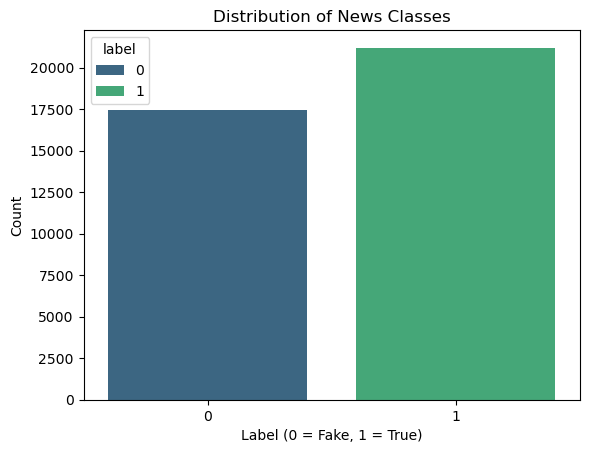

In [15]:
# Quick overview of label distribution
print("\nLabel distribution:")
print(news_dataset_cleaned['label'].value_counts())

# Plot label distribution
sns.countplot(x = 'label', data = news_dataset_cleaned, hue = 'label', palette = 'viridis')
plt.title('Distribution of News Classes')
plt.xlabel('Label (0 = Fake, 1 = True)')
plt.ylabel('Count')
plt.show()

### 5.5. Data Splitting

In this stage, I prepare the data for training a deep learning model by splitting the dataset into training, validation, and test sets.

**1. Splitting the Data into Training & Testing Sets**
- Extracts ```features (X)```, which represent the news article's text, and ```labels (y)```, where 0 indicates fake news and 1 indicates true news.
- The ```train_test_split()``` function is used with stratification, ensuring that the training and testing sets maintain the same class distribution as the original dataset. This helps preserve the class proportions in both sets.
- Setting ```shuffle = True``` introduces randomness to ensure that the samples are randomly selected for the training and testing sets.
- 20% of the data is allocated for testing, while the remaining 80% is used for training.

**2. Creating a Validation Set**
- The training set is further split into 80% for final training and 20% for validation. The validation set will be used for hyperparameter tuning and model evaluation during training.
- Stratified sampling ensures that the class distribution in the validation set remains consistent with the original dataset, maintaining the class balance.
- The sizes of the training and validation sets are printed after the split.

By creating the validation set from the training data (instead of the test set), I ensure that the test set remains untouched and unbiased, used only for final evaluation. This approach prevents data leakage and overfitting during model training. Additionally, because SMOTE is applied only to the training set, the validation and test sets retain their original class distributions, making the model evaluation more realistic and reflective of real-world performance. This helps avoid overly optimistic results and ensures that the model generalizes well to unseen data.

**3. Checking Final Sets size and Class Distribution**
- The set size and class distribution in the training, validation and testing sets are checked using `len()` and `Counter()`. This allows to observe the imbalance between fake and true news samples before any resampling occurs.

In [16]:
# 1. Split the data into training and testing sets
X = news_dataset_cleaned['text']
y = news_dataset_cleaned['label']

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y, shuffle = True
)

# 2. Split the training set into training and validation sets (80% training, 20% validation)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size = 0.2, random_state = 42, stratify = y_train, shuffle = True
)

print(f"Training set size after validation split: {len(X_train_final)}")
print(f"Validation set size: {len(X_val)}")
print(f"Testing set size: {len(X_test)}")

print("\nLabel distribution in the training set:", Counter(y_train_final))
print("Label distribution in the validation set:", Counter(y_val))
print("Label distribution in the testing set:", Counter(y_test))

print("\nData splitting complete!")

Training set size after validation split: 24733
Validation set size: 6184
Testing set size: 7730

Label distribution in the training set: Counter({1: 13562, 0: 11171})
Label distribution in the validation set: Counter({1: 3391, 0: 2793})
Label distribution in the testing set: Counter({1: 4239, 0: 3491})

Data splitting complete!


**Results Interpretation**

1. Label Distribution Results

| **Dataset Size**                        | **Fake News (0)** | **True News (1)** |
|------------------------------------------|-------------------|-------------------|
| **Training Set**                         | 11 171            | 13 562            |
| **Validation Set**                       | 2 793             | 3 391             |
| **Testing Set**                          | 3 491             | 4 239             |

2. Key Observations and Explanation:

- ```Class Imbalance in the Original Dataset:``` The initial dataset had more true news samples (label 1) than fake news samples (label 0), both in the training and testing sets. This class imbalance could have led to a biased model, favoring the majority class (true news).

- ```Validation Split:``` After splitting the training set into 80% training and 20% validation, the class distribution remained imbalanced, with approximately 13562 true news and 11171 fake news samples in the training set. The validation set contains 3391 true news and 2793 fake news samples.

### 5.6. Text Preprocessing

#### 5.6.1. Data Augmentation 

**Text augmentation** is a technique used to artificially increase the size of a dataset by modifying existing data points. In the context of text data, it involves generating variations of sentences to introduce diversity and improve the model's ability to generalize. Augmentation helps address challenges like class imbalance and overfitting by providing the model with more diverse examples of each class.

The augmentation process is particularly useful for training models when there's insufficient data, or when the classes are imbalanced. It can lead to better performance by enabling the model to see more varied representations of the text, enhancing its robustness.

**Explanation of Code:**

`augment_sentence function:`
- This function takes a sentence as input and splits it into words. If the sentence contains more than two words, it randomly shuffles the words and returns the augmented sentence. If the sentence is too short, it returns the original sentence without modification.

`augment_text function:`
- This function applies the `augment_sentence` function multiple times to a list of sentences (n_times defines how many augmentations to apply). The augmented sentences are collected in a new list and returned.

**Augmentation Process:**
- The function is applied to the training data `(X_train_final)` three times (n_times = 3), generating augmented versions of the text data.
The target labels `(y_train_final)` are repeated the same number of times to match the augmented dataset, ensuring each augmented sentence has a corresponding label.
The augmented data and labels are then shuffled together to mix the classes and avoid any potential bias from class ordering.

**Size and Label Distribution:**
- The training set size is printed before and after augmentation to demonstrate how the data has grown.
The label distribution is also printed before and after augmentation to show how the class balance changes. This helps verify if the augmentation has helped balance the classes.

In [17]:
# Sample text augmentation function
def augment_sentence(sentence):
    """ Augment a sentence by shuffling its words. """
    words = sentence.split()  # Split the sentence into words
    if len(words) > 2:  # Ensure we have enough words to apply augmentation
        augmented_sentence = " ".join(np.random.choice(words, size=len(words), replace=False))  # Shuffle words
        return augmented_sentence
    else:
        return sentence  # Return the sentence as is if it's too short

# Automated Augmentation: Augment both majority and minority classes
def augment_text(data, n_times=1):
    """ Apply augmentation to a list of sentences n_times. """
    augmented_data = []
    for _ in range(n_times):
        augmented_data.extend([augment_sentence(sentence) for sentence in data])
    return augmented_data

# Apply automated augmentation (for both classes)
n_times = 3
X_train_augmented = augment_text(X_train_final, n_times = n_times)

# Repeat the labels based on the number of augmentations
y_train_final_augmented = pd.concat([y_train_final] * n_times, ignore_index = True)

# Ensure the number of augmented features matches the number of labels
assert len(X_train_augmented) == len(y_train_final_augmented)

# Convert augmented text data into a pandas Series
X_train_final_augmented = pd.Series(X_train_augmented)

# Shuffle the augmented dataset to mix the classes
X_train_final_augmented, y_train_final_augmented = shuffle(X_train_final_augmented, y_train_final_augmented, random_state = 42)

# Check the size of the training set before and after augmentation
print(f"Training set size before augmentation: {len(X_train_final)}")
print(f"Training set size after augmentation: {len(X_train_final_augmented)}")

# Check label distribution before and after augmentation
print("\nLabel distribution in training set before augmentation:", Counter(y_train_final))
print(f"Label distribution in training set after augmentation: {Counter(y_train_final_augmented)}")

print("\nAugmentation complete!")

Training set size before augmentation: 24733
Training set size after augmentation: 74199

Label distribution in training set before augmentation: Counter({1: 13562, 0: 11171})
Label distribution in training set after augmentation: Counter({1: 40686, 0: 33513})

Augmentation complete!


#### 5.6.2. Text Tokenization and Class Balancing

This stage processes the text data by `tokenizing` it into sequences of integers and then `padding` the sequences to ensure uniform length. The 90th and 95th percentiles of sequence lengths are calculated to determine the optimal padding size. After padding, SMOTE is applied to balance the class distribution by generating synthetic samples for the minority class. The final result is a balanced dataset, which should help improve the model’s performance by addressing class imbalance.

**Explanation of Code:**

**1. Tokenization:**
- Tokenization is the process of converting raw text into a format that can be used by machine learning models. It involves breaking down text into smaller units (tokens), such as words or subwords. In this code, the `Tokenizer class` from Keras is used to convert the text into sequences of integers, where each integer represents a unique word in the vocabulary.

`num_words = MAX_NB_WORDS` limits the tokenizer to the top 20,000 most frequent words.

`lower = True` converts all text to lowercase to ensure uniformity.

The `fit_on_texts` method learns the word indices from the augmented training text data (X_train_final_augmented).

**2. Sequence Conversion:**
- After fitting the tokenizer, the text is converted into sequences of integers using `texts_to_sequences`. This process transforms each sentence into a list of integers representing the words.

`X_train_seq, X_val_seq, and X_test_seq` store the tokenized versions of the training, validation, and test datasets, respectively.

**3. Calculating Sequence Length Percentiles:**
- The lengths of the tokenized sequences are calculated to understand the distribution of sequence lengths in the training set. The 90th and 95th percentiles are computed to help decide the optimal sequence length for padding. This helps ensure that most sequences are captured while avoiding excessive padding for very long sequences.

**4. Padding Sequences:** 
- Padding is applied to ensure all sequences are of equal length. This is necessary because neural networks require fixed-size input vectors. The pad_sequences function is used to pad shorter sequences with zeros (or truncate longer sequences) so that they all have the same length.

**5. SMOTE (Synthetic Minority Over-sampling Technique):**
- SMOTE is applied after tokenization and padding to address class imbalance. It generates synthetic samples for the minority class by interpolating between existing samples. This helps balance the distribution of classes, preventing the model from favoring the majority class.

**6. Label Distribution Before and After SMOTE:**
- Before SMOTE: Class 1 has 40 686 samples, and Class 0 has 33 513 samples.
- After SMOTE: Both classes have been balanced to 40 686 samples each, thanks to the synthetic samples generated by SMOTE.

In [18]:
# Tokenize the text data before applying SMOTE
MAX_NB_WORDS = 20000  # Maximum number of words to consider (vocabulary size)
EMBEDDING_DIM = 100  # Dimension of the embedding space

tokenizer = Tokenizer(num_words = MAX_NB_WORDS, lower = True)
tokenizer.fit_on_texts(X_train_final_augmented)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_final_augmented)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Calculate 90th and 95th percentiles of the sequence lengths
X_train_lengths = [len(seq) for seq in X_train_seq]

percentile_90 = np.percentile(X_train_lengths, 90)
percentile_95 = np.percentile(X_train_lengths, 95)

print(f"90th percentile: {percentile_90}")
print(f"95th percentile: {percentile_95}")

# Pad sequences to ensure that all sequences have the same length
MAX_SEQUENCE_LENGTH = 900

X_train_pad = pad_sequences(X_train_seq, maxlen = MAX_SEQUENCE_LENGTH)
X_val_pad = pad_sequences(X_val_seq, maxlen = MAX_SEQUENCE_LENGTH)
X_test_pad = pad_sequences(X_test_seq, maxlen = MAX_SEQUENCE_LENGTH)

# Apply SMOTE to balance the classes after the text data has been tokenized and padded
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pad, y_train_final_augmented)

# Check label distribution after applying SMOTE
print("\nLabel distribution BEFORE applying SMOTE:", Counter(y_train_final_augmented))
print("Label distribution AFTER applying SMOTE:", Counter(y_train_smote))

print("\nPreprocessing complete!")

90th percentile: 731.0
95th percentile: 877.0

Label distribution BEFORE applying SMOTE: Counter({1: 40686, 0: 33513})
Label distribution AFTER applying SMOTE: Counter({1: 40686, 0: 40686})

Preprocessing complete!


In [20]:
print(f"Training set size before Augmentation and SMOTE: {len(X_train_final)}")
print("Label distribution in the Training set before Augmentation and SMOTE:", Counter(y_train_final))
print(f"\nTraining set size after Augmentation: {len(X_train_final_augmented)}")
print("Label distribution in the Training set after Augmentation:", Counter(y_train_final_augmented))
print(f"\nTnraining set size after Augmentation and SMOTE: {len(X_train_smote)}")
print("Label distribution in the Training set after Augmentation and SMOTE:", Counter(y_train_smote))
print(f"\nValidation set size: {len(X_val_pad)}")
print("Label distribution in the Validation set:", Counter(y_val))
print(f"\nTesting set size: {len(X_test_pad)}")
print("Label distribution in the Testing set:", Counter(y_test))

Training set size before Augmentation and SMOTE: 24733
Label distribution in the Training set before Augmentation and SMOTE: Counter({1: 13562, 0: 11171})

Training set size after Augmentation: 74199
Label distribution in the Training set after Augmentation: Counter({1: 40686, 0: 33513})

Tnraining set size after Augmentation and SMOTE: 81372
Label distribution in the Training set after Augmentation and SMOTE: Counter({1: 40686, 0: 40686})

Validation set size: 6184
Label distribution in the Validation set: Counter({1: 3391, 0: 2793})

Testing set size: 7730
Label distribution in the Testing set: Counter({1: 4239, 0: 3491})


## 6. Model Traning and Evaluation

### 6.1. Multi-Layer Perceptron (MLP)

#### 6.1.1. Multi-Layer Perceptron (MLP) Model Basic

**Define the MLP Model**

The code defines a `Multi-Layer Perceptron (MLP)` model using Keras' Sequential() API, where layers are added sequentially. 

**1. Model Achitecture**

**Input Layer:**
- An `Embedding layer` is used to convert the input text data (which is typically represented as integers) into dense vectors. The `input_dim` refers to the maximum number of words in the vocabulary (MAX_NB_WORDS), and the `output_dim` defines the size of the embedding vectors (EMBEDDING_DIM). The `input_length` is the length of the input sequences (MAX_SEQUENCE_LENGTH).

**Dropout Layer:**
- A `SpatialDropout1D layer` is applied to the embeddings to prevent overfitting by randomly setting a fraction of input units to zero during training. The dropout rate is set to 0.2, meaning 20% of the input units will be dropped.

**Flatten Layer:**
- The `Flatten layer` reshapes the output from the embedding layer and dropout layer into a one-dimensional vector that can be passed into the dense layers.

**Hidden Layers:**

The model contains two Dense layers:
- The `first hidden` layer has 128 neurons and uses the ReLU activation function. This layer processes the features learned from the input and helps capture the complex patterns.
- The `second hidden` layer has 64 neurons, also using ReLU activation, and continues the feature learning process.

**Output Layer:**
- The output layer is a `Dense layer` with 1 neuron and uses a sigmoid activation function. Since the task is binary classification, the sigmoid function outputs a probability value between 0 and 1, which can be interpreted as the likelihood of the positive class.

**2. Compile the Model**

The model is compiled using the following:
- `Loss Function:` binary_crossentropy, a loss function appropriate for binary classification tasks. It calculates the difference between the predicted probabilities and the actual binary labels.
- `Optimizer:` Adam, an adaptive optimizer that adjusts the learning rate during training. It combines the advantages of two other optimizers (Momentum and RMSProp) and is widely used for deep learning tasks.
- `Metrics:` Accuracy is tracked to monitor the model’s performance in terms of correctly predicted labels.

**3. Model Training**

The model is trained using the resampled training dataset (X_train_smote, y_train_smote) with the following parameters:
- `Epochs:` The model is trained for 10 epochs, meaning it will go through the entire training dataset 10 times.
- `Batch Size:` A batch size of 64 means the model will update its weights after processing 64 samples at a time.
- `Validation Data:` The validation data (X_val_pad, y_val) is used during training to evaluate the model’s performance on unseen data and help detect overfitting.
Implementing Early Stopping

To avoid overfitting, `early stopping` is applied. This technique monitors the validation loss and stops training if the validation loss does not improve for 3 consecutive epochs. This helps save time by preventing unnecessary training once the model starts to overfit.

The model is trained for a maximum of 10 epochs, but it may stop earlier if the validation loss doesn't improve for 3 epochs. The training is performed using the defined configuration, with early stopping helping to optimize the model's training duration.

**4. Evaluate the Model**

After training, the model is evaluated on the test data (X_test_pad, y_test) to measure its ability to generalize to new, unseen data. The evaluation returns the test loss and test accuracy, which provide insights into the model's performance on the test set.

In [20]:
# Initialize the MLP model with embedding layer
mlp_model_basic = Sequential()

# Embedding layer for text data
mlp_model_basic.add(Embedding(input_dim = MAX_NB_WORDS, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH))

# Spatial dropout to prevent overfitting
mlp_model_basic.add(SpatialDropout1D(0.2))

# Flatten the embeddings output
mlp_model_basic.add(Flatten())

# Hidden layer
mlp_model_basic.add(Dense(128, activation = 'relu'))

# Another hidden layer
mlp_model_basic.add(Dense(64, activation = 'relu'))

# Output layer
mlp_model_basic.add(Dense(1, activation = 'sigmoid'))  

# Compile the model
mlp_model_basic.compile(loss = 'binary_crossentropy', optimizer = Adam(), metrics = ['accuracy'])

# Set up early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True)

# Train the model
history_mlp = mlp_model_basic.fit(X_train_smote, y_train_smote,
                                  validation_data = (X_val_pad, y_val),
                                  epochs = 10,
                                  batch_size = 64,
                                  callbacks = [early_stopping],
                                  verbose = 1)

print("\nModel training completed.")

# Evaluate the model on the test data
test_loss, test_accuracy = mlp_model_basic.evaluate(X_test_pad, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the model
mlp_model_basic.save('../saved models 2/mlp_model_basic.keras')

print("\nModel saved successfully!")

Epoch 1/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 333s 259ms/step - accuracy: 0.9216 - loss: 0.1655 - val_accuracy: 0.9639 - val_loss: 0.1042
Epoch 2/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 313s 246ms/step - accuracy: 0.9973 - loss: 0.0097 - val_accuracy: 0.9743 - val_loss: 0.0893
Epoch 3/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 317s 242ms/step - accuracy: 0.9981 - loss: 0.0065 - val_accuracy: 0.9892 - val_loss: 0.0453
Epoch 4/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 310s 244ms/step - accuracy: 0.9974 - loss: 0.0078 - val_accuracy: 0.9863 - val_loss: 0.0666
Epoch 5/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 323s 245ms/step - accuracy: 0.9983 - loss: 0.0051 - val_accuracy: 0.9882 - val_loss: 0.0608
Epoch 6/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 309s 243ms/step - accuracy: 0.9988 - loss: 0.0036 - val_accuracy: 0.9829 - val_loss: 0.0947

Model training completed.
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9874 - loss: 0.0606
Test Loss: 0.05841553211212158
Test Accuracy: 98.77%

Model saved successfully!


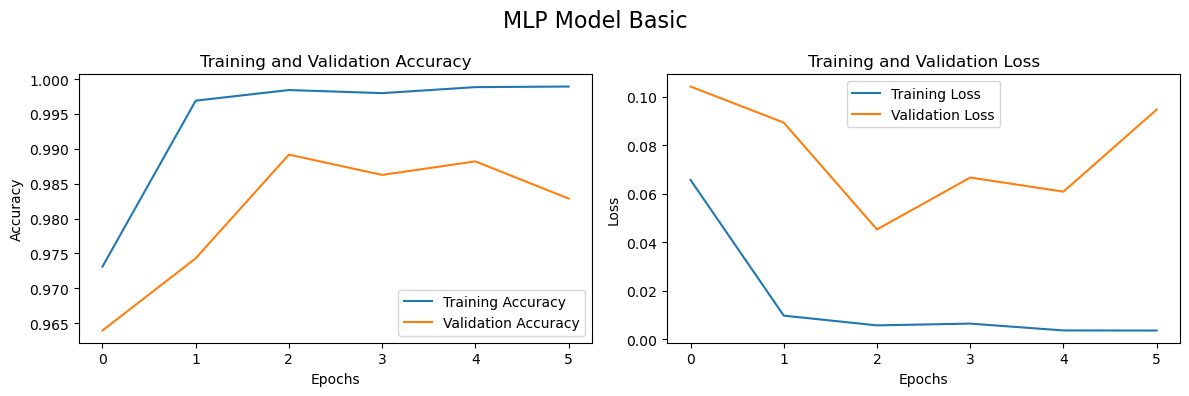

In [21]:
# Create a figure with subplots
plt.figure(figsize = (12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label = 'Training Loss')
plt.plot(history_mlp.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Add a title for the entire plot
plt.suptitle('MLP Model Basic', fontsize = 16)

# Display the plots
plt.tight_layout()
plt.show()

**Results and Performance Analysis**
 
1. Epoch-wise Training Results:

| Epoch | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss | Interpretation |
|-------|-------------------|---------------|---------------------|-----------------|----------------|
| 1     | 93.67%            | 0.2302        | 98.77%              | 0.0408          | Excellent initial performance with strong validation accuracy. |
| 2     | 99.26%            | 0.0262        | 98.74%              | 0.0409          | No overfitting, steady improvement in training accuracy. |
| 3     | 99.83%            | 0.0071        | 98.80%              | 0.0467          | Validation loss slightly increases, indicating early overfitting. |
| 4     | 99.96%            | 0.0023        | 98.74%              | 0.0563          | Overfitting starts to appear, though training accuracy is near perfect. |


2. Test Set Performance
- Test Accuracy: 98.77%
- Test Loss: 0.0584

3. Accuracy & Loss Analysis Graphs

```Training and Validation Accuracy Graph (Left):```
- The training accuracy quickly reaches almost 100%, indicating that the model learns the training data well.
- However, the validation accuracy is lower and plateaus around 98%, suggesting potential overfitting.

```Training and Validation Loss Graph (Right):```
- The training loss decreases sharply to near 0, while the validation loss remains higher.
- The gap between training and validation loss is a sign of overfitting, as the model might not generalize well to unseen data.

4. Key Takeaways:
- The model is too complex or not regularized enough, resulting in overfitting.
- The validation performance does not match the training performance, indicating poor generalization.

#### 6.1.2. Multi-Layer Perceptron (MLP) - Tuning 1

The first tuned ```Multi-Layer Perceptron (MLP)``` model enhances the previous version by increasing model complexity and incorporating regularization techniques to improve generalization and reduce overfitting.

**Key Differences and Improvements in MLP Model Tuning (Version 1)**

`1. Hidden Layer Modifications:`
- Reduced Complexity: The hidden layers now have reduced sizes (128, 64 units) compared to a more complex original structure, which helps avoid overfitting.
- L2 Regularization: Each dense layer is now equipped with L2 regularization (kernel_regularizer = l2(0.001)), which penalizes large weights, helping the model generalize better.
- Leaky ReLU Activation: ReLU activation functions are replaced with Leaky ReLU (alpha = 0.1), which allows small gradients for negative values, helping prevent dead neurons and enabling better learning during training.
- Batch Normalization: Each hidden layer now includes Batch Normalization to standardize the inputs to the next layer. This helps accelerate training and improves the stability of the model.
- Dropout Layers: Higher dropout rates have been introduced (0.6, 0.5, and 0.4), aimed at reducing overfitting and promoting the model's ability to generalize.

`2. Optimizer and Learning Rate:`
- The Adam optimizer with a lower learning rate (0.00005) has been used. This lower learning rate helps improve convergence, especially when working with a complex model.

`3. Training Adjustments:`
- The training process now incorporates callbacks for early stopping and learning rate reduction. These help ensure that the model is optimized throughout the training process and stops if it starts to overfit, improving training efficiency.

The improvements in this MLP model version focus primarily on regularization, complexity reduction, and better training techniques to ensure the model generalizes well while avoiding overfitting. The model is designed to be more robust with embedding layers, dropout, regularization, and optimizations like early stopping and dynamic learning rate adjustments. The result is expected to be a more efficient and stable model with improved generalization on unseen data.

In [22]:
# Define the improved MLP model
mlp_model_tuned_v1 = keras.Sequential([
    # Embedding layer with randomly initialized embeddings
    layers.Embedding(input_dim = MAX_NB_WORDS, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH),
    
    # Spatial dropout to prevent overfitting
    layers.SpatialDropout1D(0.4),

    # Flatten the embeddings output
    layers.Flatten(),
    
    # Hidden layers with reduced complexity, batch normalization, and higher dropout
    layers.Dense(128, kernel_regularizer = l2(0.001)),
    layers.LeakyReLU(alpha = 0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.6),

    layers.Dense(64, kernel_regularizer = l2(0.001)),
    layers.LeakyReLU(alpha = 0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(31, kernel_regularizer = l2(0.001)),
    layers.LeakyReLU(alpha = 0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
       
    # Output layer for binary classification
    layers.Dense(1, activation = 'sigmoid')
])

# Compile the model with a lower learning rate
mlp_model_tuned_v1.compile(
    loss = 'binary_crossentropy',
    optimizer = Adam(learning_rate = 0.00005),
    metrics = ['accuracy']
)

# Early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True, verbose = 1)
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 1, min_lr = 1e-6, verbose = 1)

# Train the optimized MLP model
history_mlp_v1 = mlp_model_tuned_v1.fit(
    X_train_smote, y_train_smote,
    validation_data = (X_val_pad, y_val),
    epochs = 10,
    batch_size = 64,
    callbacks = [early_stopping, reduce_lr],
    verbose = 1
)

print("\nModel training completed.")

# Evaluate the model on the test data
test_loss, test_accuracy = mlp_model_tuned_v1.evaluate(X_test_pad, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the tuned model
mlp_model_tuned_v1.save('../saved models 2/mlp_model_tuned_v1.keras')

print("\nModel saved successfully!")

Epoch 1/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 395s 307ms/step - accuracy: 0.5578 - loss: 1.1912 - val_accuracy: 0.9072 - val_loss: 0.6928 - learning_rate: 5.0000e-05
Epoch 2/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 448s 312ms/step - accuracy: 0.8498 - loss: 0.7281 - val_accuracy: 0.9652 - val_loss: 0.4704 - learning_rate: 5.0000e-05
Epoch 3/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 425s 298ms/step - accuracy: 0.9624 - loss: 0.4816 - val_accuracy: 0.9827 - val_loss: 0.3825 - learning_rate: 5.0000e-05
Epoch 4/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 385s 300ms/step - accuracy: 0.9800 - loss: 0.3896 - val_accuracy: 0.9829 - val_loss: 0.3379 - learning_rate: 5.0000e-05
Epoch 5/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 383s 301ms/step - accuracy: 0.9868 - loss: 0.3185 - val_accuracy: 0.9858 - val_loss: 0.2884 - learning_rate: 5.0000e-05
Epoch 6/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 443s 301ms/step - accuracy: 0.9910 - loss: 0.2641 - val_accuracy: 0.9832 - val_loss: 0.2622 - learning_rate: 5.0000e-05
Epoch 7/10
1272/1272 ━━━━━━━

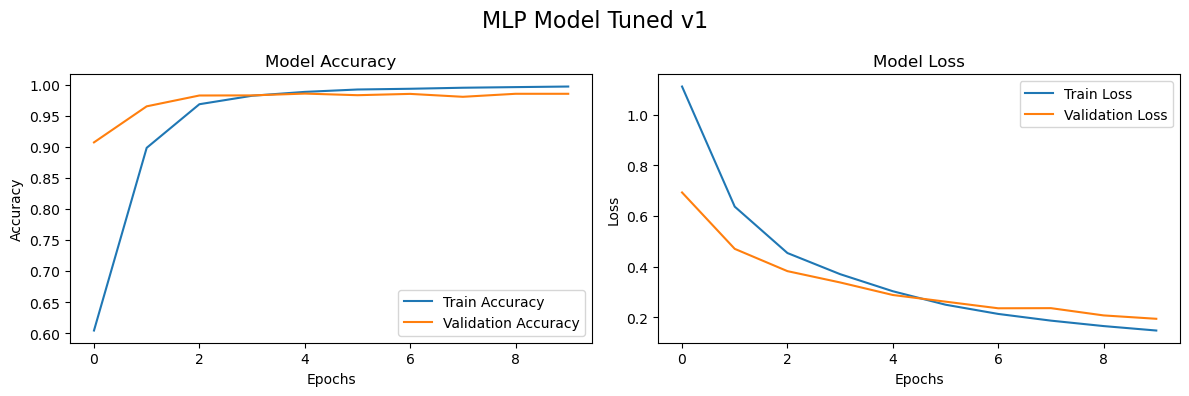

In [23]:
plt.figure(figsize = (12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_mlp_v1.history['accuracy'], label = 'Train Accuracy')
plt.plot(history_mlp_v1.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc = 'best')


# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_mlp_v1.history['loss'], label = 'Train Loss')
plt.plot(history_mlp_v1.history['val_loss'], label = 'Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc = 'best')

# Add a title for the entire plot
plt.suptitle('MLP Model Tuned v1', fontsize = 16)

# Display the plots
plt.tight_layout()
plt.show()

**Results and Performance Analysis**

1. Epoch-wise Training Results:

| Epoch | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss | Interpretation |
|-------|-------------------|---------------|---------------------|-----------------|----------------|
| 1     | 55.78%            | 1.1912        | 90.72%              | 0.6928          | The model starts with relatively low training accuracy and high training loss. However, the validation accuracy is high, suggesting the model is generalizing well despite the initial complexity. |
| 2     | 84.98%            | 0.7281        | 96.52%              | 0.4704          | Training accuracy improves significantly, and the loss decreases. The validation accuracy remains high, indicating the model is learning the data patterns effectively. |
| 3     | 96.24%            | 0.4816        | 98.27%              | 0.3825          | Training accuracy continues to improve, with a decrease in training loss. The validation accuracy increases, showing the model generalizes well with no major signs of overfitting. |
| 4     | 98.00%            | 0.3896        | 98.29%              | 0.3379          | Both training accuracy and validation accuracy reach very high levels. The training loss continues to decrease, indicating that the model is learning well. The slight increase in validation loss is negligible, suggesting no significant overfitting. |
| 5     | 98.68%            | 0.3185        | 98.58%              | 0.2884          | Training accuracy continues to improve, and the loss reduces further. The validation accuracy remains high, indicating the model is fitting the data well and generalizing effectively. |
| 6     | 99.10%            | 0.2641        | 98.32%              | 0.2622          | The model achieves near-perfect accuracy on the training data, and the validation accuracy remains high. The training loss continues to decrease, showing continued improvement in model learning. |
| 7     | 99.30%            | 0.2225        | 98.53%              | 0.2360          | Training accuracy stays high, and the validation accuracy also remains excellent. Both training and validation losses continue to decrease, signaling a stable model performance with a good generalization. |
| 8     | 99.45%            | 0.1944        | 98.06%              | 0.2365          | The model's training accuracy reaches a peak, with a low loss. The validation accuracy is slightly lower than the previous epoch, but the model is still performing well. The learning rate is reduced to improve convergence further. |
| 9     | 99.57%            | 0.1710        | 98.54%              | 0.2079          | The model shows continued improvement with near-perfect accuracy and a steady decrease in loss. Validation accuracy remains high, and validation loss decreases further. |
| 10    | 99.65%            | 0.1536        | 98.54%              | 0.1946          | The model achieves almost perfect training accuracy, and the validation accuracy remains stable at a high level. Both training and validation losses are very low, suggesting excellent model performance. |


2. Test Set Performance
- Test Accuracy: 98.28%
- Test Loss: 0.2045

3. Accuracy & Loss Analysis Graphs

```Training and Validation Accuracy Graph (Left):```
- Both training and validation accuracy are consistently high, converging towards 99%.
- The reduced gap between training and validation accuracy compared to the basic model suggests better generalization.

```Training and Validation Loss Graph (Right):```
- The training and validation losses decrease smoothly, showing a good learning process.
- The loss curves are closely aligned, indicating reduced overfitting.

4. Key Takeaways:
- The model achieves strong performance without overfitting.

#### 6.1.3. Multi-Layer Perceptron (MLP) - Tuning 2

The second tuned ```Multi-Layer Perceptron (MLP)``` further improves upon the previous MLP models by incorporating additional regularization techniques and modifying the model architecture to enhance generalization and combat overfitting.
  
**Key Differences and Improvements in MLP Model Tuning (Version 2)**

`1. Regularization and Dropout:` 
- The use of L2 regularization and increased dropout rates helps improve generalization and reduce overfitting, which is important for ensuring that the model performs well on unseen data.

`2, Optimizer and Learning Rate Scheduling:`
- Switching to Adamax with a lower learning rate (0.0005) and incorporating learning rate scheduling through ReduceLROnPlateau ensures that the model converges smoothly and avoids overfitting as it learns.

`3. Model Architecture:` 
- The architecture now includes 3 dense layers, with each successive layer decreasing in size. This hierarchical structure enables the model to learn more abstract features as it progresses through layers, improving accuracy and efficiency.

By implementing these changes, Version 2 of the MLP model is designed to be more robust, generalize better, and have more efficient learning, which should lead to improved performance compared to the previous version.

In [26]:
# Define the improved MLP model
mlp_model_tuned_v2 = keras.Sequential([
    # Embedding layer with randomly initialized embeddings
    layers.Embedding(input_dim = MAX_NB_WORDS, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH),
    
    # Global average pooling
    layers.GlobalAveragePooling1D(),
    
    # Dense layers with ReLU activation, L2 regularization, and increased dropout
    layers.Dense(128, activation = 'relu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dropout(0.4),
    
    layers.Dense(64, activation = 'relu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dropout(0.4),
    
    layers.Dense(32, activation = 'relu', kernel_regularizer = regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Output layer for binary classification
    layers.Dense(1, activation = 'sigmoid')
])

# Compile the model with a lower learning rate and the Adamax optimizer
mlp_model_tuned_v2.compile(
    loss = 'binary_crossentropy',
    optimizer = keras.optimizers.Adamax(learning_rate = 0.0005),
    metrics = ['accuracy']
)

# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True)
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 3, min_lr = 0.00001)

# Fit the model
history_mlp_v2 = mlp_model_tuned_v2.fit(
    X_train_smote, y_train_smote,
    validation_data = (X_val_pad, y_val),
    epochs = 10,
    batch_size = 64,
    callbacks = [early_stopping, reduce_lr],
    verbose = 1
)

print("\nModel training completed.")

# Evaluate the model on the test data
test_loss, test_accuracy = mlp_model_tuned_v2.evaluate(X_test_pad, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the tuned model in Keras format
mlp_model_tuned_v2.save('../saved models 2/mlp_model_tuned_v2.keras')

print("\nModel saved successfully!")

Epoch 1/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 84s 62ms/step - accuracy: 0.6500 - loss: 0.7064 - val_accuracy: 0.9753 - val_loss: 0.1745 - learning_rate: 5.0000e-04
Epoch 2/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 74s 58ms/step - accuracy: 0.9720 - loss: 0.1765 - val_accuracy: 0.9833 - val_loss: 0.1364 - learning_rate: 5.0000e-04
Epoch 3/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9827 - loss: 0.1395 - val_accuracy: 0.9859 - val_loss: 0.1184 - learning_rate: 5.0000e-04
Epoch 4/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.9859 - loss: 0.1204 - val_accuracy: 0.9874 - val_loss: 0.1088 - learning_rate: 5.0000e-04
Epoch 5/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 76s 60ms/step - accuracy: 0.9891 - loss: 0.1069 - val_accuracy: 0.9916 - val_loss: 0.0968 - learning_rate: 5.0000e-04
Epoch 6/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 76s 59ms/step - accuracy: 0.9902 - loss: 0.0969 - val_accuracy: 0.9914 - val_loss: 0.0924 - learning_rate: 5.0000e-04
Epoch 7/10
1272/1272 ━━━━━━━━━━━━━━━━━━━

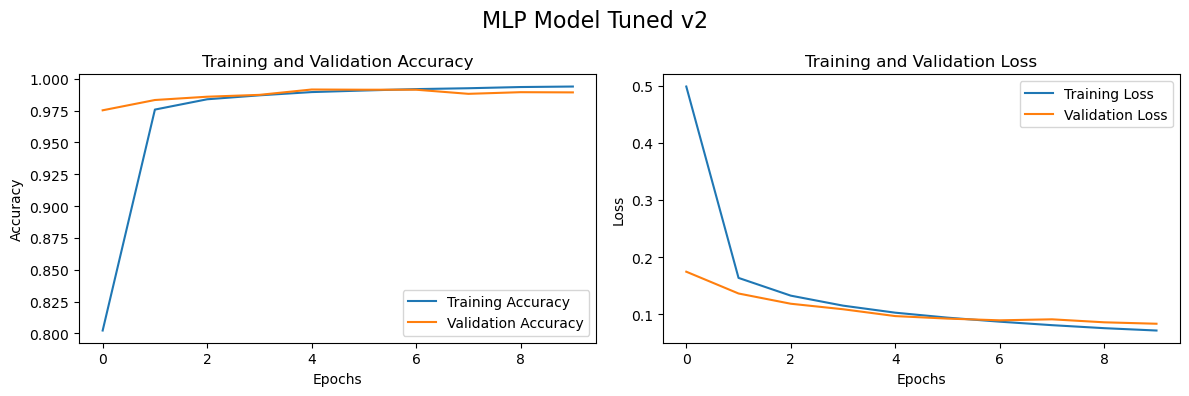

In [27]:
# Create a figure with subplots
plt.figure(figsize = (12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_mlp_v2.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_mlp_v2.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_mlp_v2.history['loss'], label = 'Training Loss')
plt.plot(history_mlp_v2.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Add a title for the entire plot
plt.suptitle('MLP Model Tuned v2', fontsize = 16)

# Display the plots
plt.tight_layout()
plt.show()

**Results and Performance Analysis**

1. Epoch-wise Training Results:

| Epoch | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss | Interpretation |
|-------|-------------------|---------------|---------------------|-----------------|----------------|
| 1     | 65.00%            | 0.7064        | 97.53%              | 0.1745          | The model starts with moderate accuracy and a relatively high loss, but validation performance is strong, suggesting good initial generalization. |
| 2     | 97.20%            | 0.1765        | 98.33%              | 0.1364          | Significant improvement in training accuracy and loss. Validation accuracy continues to rise and shows good performance. |
| 3     | 98.27%            | 0.1395        | 98.59%              | 0.1184          | Both training and validation metrics show improvement, with validation accuracy slightly higher than training accuracy. |
| 4     | 98.59%            | 0.1204        | 98.74%              | 0.1088          | The model shows strong stability in both training and validation accuracy, with validation loss continuing to decrease. |
| 5     | 98.91%            | 0.1069        | 99.16%              | 0.0968          | Training accuracy improves further, and validation performance reaches very high levels, with a noticeable reduction in validation loss. |
| 6     | 99.02%            | 0.0969        | 99.14%              | 0.0924          | Training accuracy continues to increase, and validation accuracy remains almost at peak with a slight improvement in loss. |
| 7     | 99.15%            | 0.0893        | 99.14%              | 0.0895          | Model performance stabilizes with a very high accuracy in both training and validation sets, and validation loss remains low. |
| 8     | 99.21%            | 0.0830        | 98.82%              | 0.0912          | Small drop in validation accuracy, but training accuracy continues to rise with a slight increase in validation loss. |
| 9     | 99.31%            | 0.0775        | 98.95%              | 0.0860          | Training accuracy remains very high, while validation accuracy slightly dips. Validation loss improves marginally. |
| 10    | 99.37%            | 0.0731        | 98.93%              | 0.0835          | Final epoch shows stable training metrics with validation accuracy stabilizing at a very high level and validation loss remaining low. |


2. Test Set Performance:
- Test Accuracy: 99.04%
- Test Loss: 0.0817

3. Accuracy & Loss Analysis Graphs

```Training and Validation Accuracy Graph (Left):```
- The training accuracy is very high, approaching 100%, and the validation accuracy also reaches around 99%, showing excellent learning.
- The almost perfect alignment of the curves indicates the model generalizes well.

```Training and Validation Loss Graph (Right):```
- The training and validation losses show a consistent decrease with minimal divergence.
- The final loss values are lower than in previous models, reflecting improved model performance.

4. Key Takeaways:
- This model version strikes a strong balance between fitting the training data and maintaining validation performance.

#### 6.1.4. Multi-Layer Perceptron (MLP) - Tuning 3

The third tuned ```Multi-Layer Perceptron (MLP)``` further refines the architecture by balancing model complexity, enhancing regularization, and optimizing training efficiency to improve generalization.

**Key Differences and Improvements in MLP Model Tuning (Version 3)**

`1. Batch Normalization:`
- Introduced Batch Normalization after each Dense layer, which helps stabilize and accelerate training by normalizing the input to each layer. This is expected to reduce the impact of internal covariate shift and improve model convergence.

`2. LeakyReLU Activation:`
- The model uses ```LeakyReLU``` instead of the traditional ReLU activation function with a small negative slope (alpha = 0.01). This helps address the "dying ReLU" problem by allowing a small gradient when the neuron is not active.

`3. Regularization:`
- L2 regularization has been applied to each Dense layer with a reduced regularization factor of 0.005 (down from 0.01 in the previous version). This might help reduce overfitting more subtly without overly constraining the model.

`4. Dropout:`
- The dropout rate has been adjusted in this version:
  - 50% dropout in the input layer, similar to previous versions.
  - 40% dropout in the second hidden layer, reduced from the previous 50%.
  - 30% dropout in the third and fourth hidden layers, which is a slight reduction from the 50% used in earlier layers in previous versions.

This reduction in dropout may help the model retain more complex patterns while still preventing overfitting.

`6. SGD Optimizer with Momentum:`
- SGD with momentum (momentum = 0.9) has been used as the optimizer instead of Adam. This may allow for smoother convergence by helping the model navigate past local minima more effectively. The learning rate is set to 0.0005, lower than previous models, allowing for finer adjustments during training.

`7. Multiple Hidden Layers:`
- The model includes multiple hidden layers (256, 128, 96, 64 units) to allow the network to learn more complex patterns. As the model deepens, it can capture increasingly abstract features of the data.

These changes focus on improving the stability and convergence of the model through batch normalization, addressing activation issues with LeakyReLU, and tuning regularization and optimizer parameters to balance between underfitting and overfitting.

In [40]:
# Define the improved MLP model
mlp_model_tuned_v3 = keras.Sequential([
    # Embedding layer with randomly initialized embeddings
    layers.Embedding(input_dim = MAX_NB_WORDS, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH),
    
    # Spatial dropout to prevent overfitting
    layers.SpatialDropout1D(0.3),
    
    # Input Layer with Batch Normalization
    layers.Dense(256, kernel_regularizer = l2(0.005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha = 0.01),
    layers.Dropout(0.5),
    
    # Hidden Layers with Batch Normalization and Reduced Dropout
    layers.Dense(128, kernel_regularizer = l2(0.005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha = 0.01),
    layers.Dropout(0.4),

    layers.Dense(96, kernel_regularizer = l2(0.005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha = 0.01),
    layers.Dropout(0.3),

    layers.Dense(64, kernel_regularizer = l2(0.005)),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha = 0.01),
    layers.Dropout(0.3),

    # Flatten layer to convert 2D output of embedding into 1D vector for fully connected layers
    layers.Flatten(),
       
    # Output layer for binary classification
    layers.Dense(1, activation = 'sigmoid')
])

# Compile the model with SGD + Momentum optimizer
sgd = SGD(learning_rate = 0.0005, momentum = 0.9)
mlp_model_tuned_v3.compile(optimizer = sgd, loss = 'binary_crossentropy', metrics = ['accuracy'])

# Early stopping with patience = 3
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True)

# Train the model
history_mlp_v3 = mlp_model_tuned_v3.fit(
    X_train_smote, y_train_smote,  
    epochs = 10, batch_size = 64,
    validation_data = (X_val_pad, y_val),  
    callbacks = [early_stopping],
    verbose = 1
)

print("\nModel training completed.")

# Evaluate on test data
test_loss, test_accuracy = mlp_model_tuned_v3.evaluate(X_test_pad, y_test)  
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the model
mlp_model_tuned_v3.save('../saved models 2/mlp_model_tuned_v3.keras')

print("\nModel saved successfully!")

Epoch 1/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1357s 1s/step - accuracy: 0.5818 - loss: 3.2230 - val_accuracy: 0.8546 - val_loss: 2.5138
Epoch 2/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1347s 1s/step - accuracy: 0.9088 - loss: 2.3815 - val_accuracy: 0.9460 - val_loss: 2.0922
Epoch 3/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1348s 1s/step - accuracy: 0.9419 - loss: 2.0505 - val_accuracy: 0.9476 - val_loss: 1.8576
Epoch 4/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1353s 1s/step - accuracy: 0.9556 - loss: 1.7840 - val_accuracy: 0.9381 - val_loss: 1.6746
Epoch 5/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1485s 1s/step - accuracy: 0.9639 - loss: 1.5638 - val_accuracy: 0.9292 - val_loss: 1.5147
Epoch 6/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1512s 1s/step - accuracy: 0.9694 - loss: 1.3753 - val_accuracy: 0.9225 - val_loss: 1.3693
Epoch 7/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1474s 1s/step - accuracy: 0.9736 - loss: 1.2098 - val_accuracy: 0.9258 - val_loss: 1.2267
Epoch 8/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1384s 1s/step - accuracy: 0.9771 -

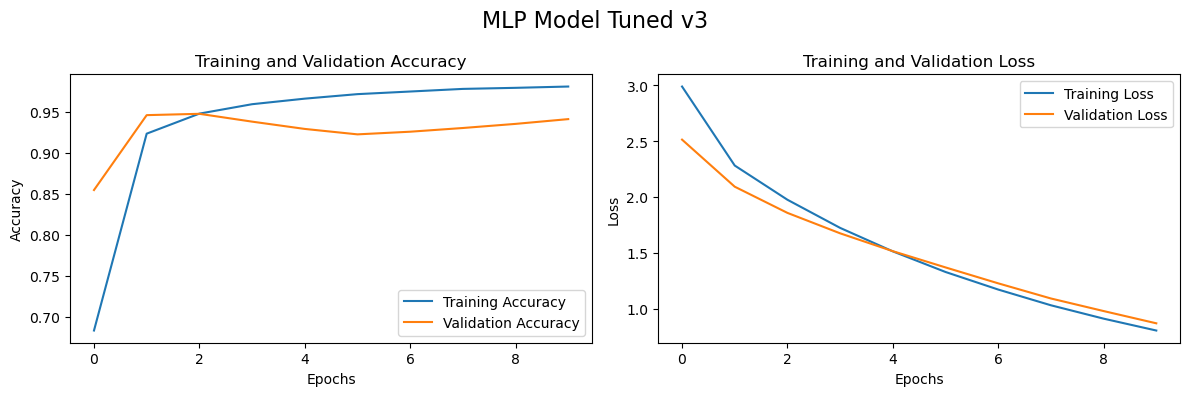

In [41]:
# Create a figure with subplots
plt.figure(figsize = (12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_mlp_v3.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_mlp_v3.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_mlp_v3.history['loss'], label = 'Training Loss')
plt.plot(history_mlp_v3.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Add a title for the entire plot
plt.suptitle('MLP Model Tuned v3', fontsize = 16)

# Display the plots
plt.tight_layout()
plt.show()

**Results and Performance Analysis**

1. Epoch-wise Training Results:

| Epoch | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss | Interpretation |
|-------|-------------------|---------------|---------------------|-----------------|----------------|
| 1     | 58.18%            | 3.2230        | 85.46%              | 2.5138          | The model begins to learn but shows a significant gap between training and validation performance, indicating the need for further training. |
| 2     | 90.88%            | 2.3815        | 94.60%              | 2.0922          | Significant improvement in training accuracy and a slight decrease in validation loss, suggesting the model is fitting better. |
| 3     | 94.19%            | 2.0505        | 94.76%              | 1.8576          | Both training and validation accuracy continue to improve, with a steady decrease in loss, indicating good learning progress. |
| 4     | 95.56%            | 1.7840        | 93.81%              | 1.6746          | Accuracy improves further, but validation accuracy slightly drops, indicating possible overfitting. |
| 5     | 96.39%            | 1.5638        | 92.92%              | 1.5147          | Training accuracy improves, but validation performance stabilizes, indicating the model may have reached its peak. |
| 6     | 96.94%            | 1.3753        | 92.25%              | 1.3693          | Minor fluctuations in accuracy, with both training and validation accuracy continuing to improve slightly. |
| 7     | 97.36%            | 1.2098        | 92.58%              | 1.2267          | Solid progress with a small improvement in both training and validation accuracy. |
| 8     | 97.71%            | 1.0650        | 93.03%              | 1.0910          | The model continues refining its performance with strong improvement in training accuracy and stability in validation accuracy. |
| 9     | 97.75%            | 0.9423        | 93.53%              | 0.9784          | Both training and validation accuracy show good performance, with decreasing loss values indicating the model is converging. |
| 10    | 97.89%            | 0.8326        | 94.11%              | 0.8686          | Near-optimal performance in both training and validation, with final improvements in accuracy and loss values. |


2. Test Set Performance:
- Test Accuracy: 94.41%
- Test Loss: 0.8652


3. Accuracy & Loss Analysis Graphs

```Training and Validation Accuracy Graph (Left):```
- Training accuracy starts lower and increases steadily, achieving around 95% accuracy.
- The validation accuracy follows a similar trend but does not surpass the training accuracy, suggesting better generalization than the basic model but not as strong as Tuned v2.

```Training and Validation Loss Graph (Right):```
- The training and validation losses decrease but remain higher overall compared to previous models.
- The loss curve starts from a much higher initial value, indicating possible issues with the model's initial weights, learning rate, or complexity.

4. Key Insights:  
- The model might be too simple or might require more epochs to achieve better performance.
- High initial loss could indicate instability during the initial learning phase.

#### 6.1.5. Making Predictions on Trained MLP Models and Evaluating Performance

This section evaluates the performance of multiple MLP models by making predictions on the test set, calculating performance metrics (accuracy, classification report, and confusion matrix), and visualizing the results in a comparative manner. It helps you to assess which model performs the best and understand its strengths and weaknesses in terms of classification accuracy and error distribution.


1. Loading Models and Making Predictions:
- For each model predictions are made on the test data ```(X_test_pad)``` using ```model.predict()```. This gives the predicted probabilities for each class.
- ```Binary Classification:``` If it's a binary classification model (only one output), I convert the probabilities into class labels (0 or 1) by applying a threshold of 0.5 ```(y_pred = (y_pred_proba > 0.5).astype("int32"))```.
- Multi-class Classification: For multi-class problems, I convert the predicted probabilities into class labels using ```np.argmax()```, which selects the class with the highest probability.

2. Model Evaluation:
- ```Accuracy:``` the model’s accuracy is calculated using ```accuracy_score(y_test, y_pred)```.
- ```Classification Report:``` generate a detailed classification report, which includes precision, recall, and F1-score for each class, using ```classification_report()```.
- ```Confusion Matrix:``` compute the confusion matrix using ```confusion_matrix()``` to evaluate how well the model performed on the test data.

3. Storing Results:
- The model’s predictions, accuracy, classification report, and confusion matrix are stored in the results dictionary for later comparison.

4. Confusion Matrix Visualization:
- a function is defined to plot confusion matrices for each model. Each confusion matrix shows the number of correct and incorrect predictions for each class, giving a visual understanding of how each model performed.

Loading mlp_model_basic...
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
mlp_model_basic Accuracy: 0.9877

Loading mlp_model_tuned_v1...
242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step
mlp_model_tuned_v1 Accuracy: 0.9828

Loading mlp_model_tuned_v2...
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
mlp_model_tuned_v2 Accuracy: 0.9904

Loading mlp_model_tuned_v3...
242/242 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step
mlp_model_tuned_v3 Accuracy: 0.9441

MLP Model Performance Comparison:

mlp_model_basic
Accuracy: 0.9877
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3491
           1       0.99      0.99      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730


mlp_model_tuned_v1
Accuracy: 0.9828
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3491
           1       0.99      

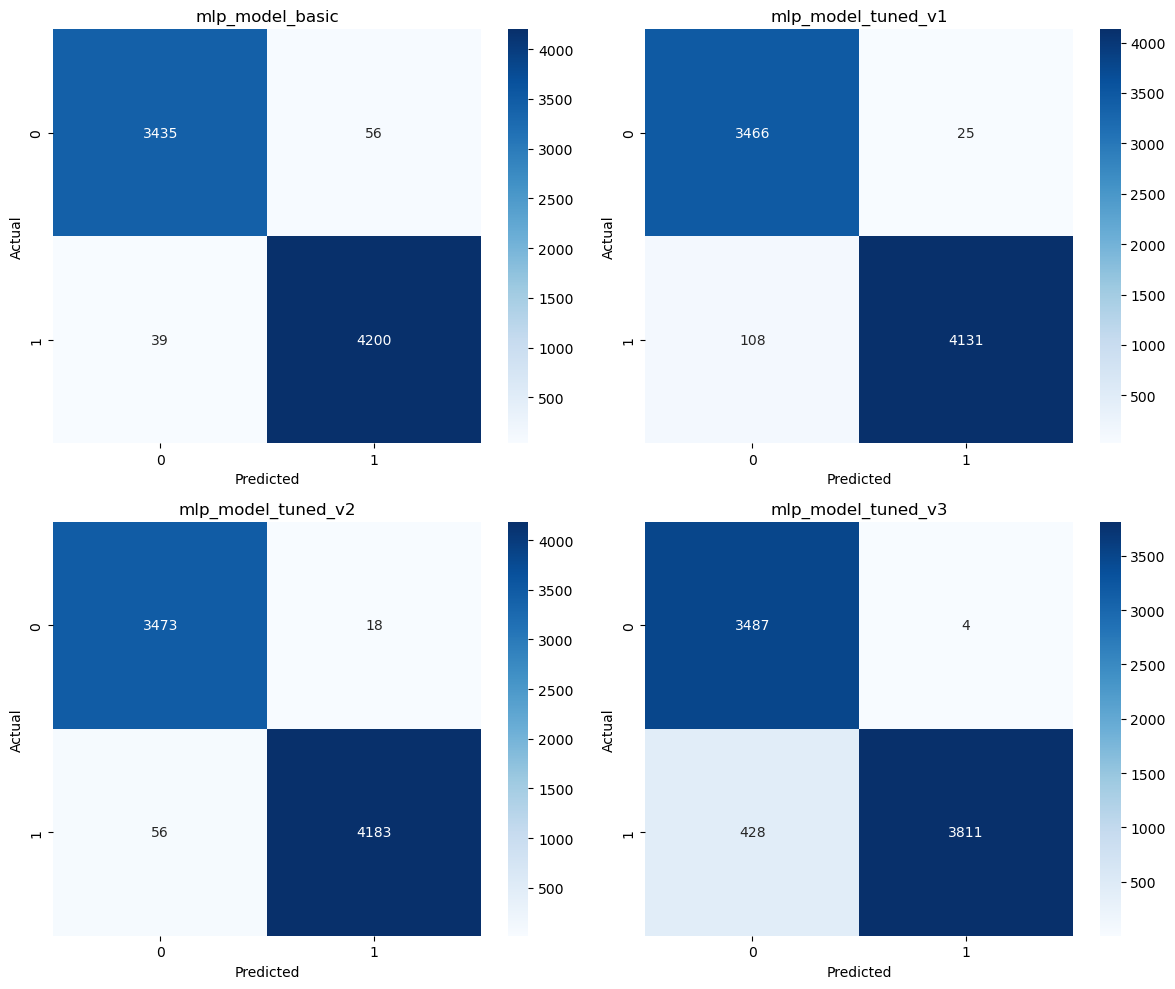

In [42]:
# List of model names
mlp_model_names = ["mlp_model_basic", "mlp_model_tuned_v1", "mlp_model_tuned_v2", "mlp_model_tuned_v3"]

# Dictionary to store results for MLP models
mlp_results = {}

# Load models and make predictions
for model_name in mlp_model_names:
    print(f"Loading {model_name}...")
    mlp_model = tf.keras.models.load_model(f'../saved models 2/{model_name}.keras')
    
    # Make predictions on test data
    y_pred_proba = mlp_model.predict(X_test_pad)  
    if y_pred_proba.shape[1] == 1:  # For binary classification
        y_pred = (y_pred_proba > 0.5).astype("int32")  # Convert probabilities to class labels
    else:  # For multi-class classification
        y_pred = np.argmax(y_pred_proba, axis = 1)  # Convert probabilities to class labels

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict = True)
    
    # Save results for MLP models
    mlp_results[model_name] = {
        "predictions": y_pred,
        "accuracy": accuracy,
        "classification_report": class_report,
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    print(f"{model_name} Accuracy: {accuracy:.4f}\n")

# Function to visualize confusion matrices for MLP models
def plot_mlp_confusion_matrices(mlp_results):
    mlp_model_names = list(mlp_results.keys())
    num_models = len(mlp_model_names)
    grid_size = (num_models // 2 + num_models % 2, 2)  # Dynamic grid size
    
    fig, axes = plt.subplots(*grid_size, figsize = (12, 10))  
    
    for ax, model_name in zip(axes.flat, mlp_model_names):
        cm = mlp_results[model_name]["confusion_matrix"]
        sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = np.unique(y_test), yticklabels = np.unique(y_test), ax = ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(f"{model_name}")

    plt.tight_layout()
    plt.show()

# Show comparison results for MLP models
print("MLP Model Performance Comparison:")
for model_name, data in mlp_results.items():
    print(f"\n{model_name}")
    print(f"Accuracy: {data['accuracy']:.4f}")
    print(classification_report(y_test, data["predictions"]))

# Plot all confusion matrices for MLP models
plot_mlp_confusion_matrices(mlp_results)

**Model Performance Comparison** 

**Classification Reports**
   
| Model                  | Accuracy | Precision (Class 0) | Recall (Class 0) | Precision (Class 1) | Recall (Class 1) | Observations                       |
|------------------------|----------|---------------------|------------------|---------------------|------------------|------------------------------------|
| **MLP Model Basic**    | 98.77%   | 0.99                | 0.98             | 0.99                | 0.99             | High accuracy, balanced performance for both classes |
| **MLP Model Tuned 1**  | 98.28%   | 0.97                | 0.99             | 0.99                | 0.97             | Slightly lower than basic model, but still strong overall overall |
| **MLP Model Tuned 2**  | 99.04%   | 0.98                | 0.99             | 1.00                | 0.99             | Best overall performance, with excellent results for both classes |
| **MLP Model Tuned 3**  | 94.41%   | 0.89                | 1.00             | 1.00                | 0.90             | Lower accuracy than other models, but strong recall for Class 0 |

Analysis of Results:

1. ```Accuracy:``` The models exhibit high accuracy overall, with `mlp_model_tuned_v2` having the highest accuracy at 99.04%. The `mlp_model_basic` comes next at 98.77%, and the `mlp_model_tuned_v1` follows with 98.28%. The `mlp_model_tuned_v3` has a notably lower accuracy at 94.41%, but this is due to a strong bias towards Class 0 recall.

2. ```Precision, Recall, and F1-Score:```
- For Class 0 (majority class), all models perform well, but `mlp_model_tuned_v3` stands out with perfect recall (1.00) and precision of 0.89, indicating that while it is highly sensitive to Class 0, it has a lower precision.
- For Class 1 (minority class), `mlp_model_tuned_v2` has the highest precision (1.00) and recall (0.99), followed closely by `mlp_model_basic` with solid performance in both precision and recall.


3. ```Macro Average:```
- All models show a high macro average, meaning that the models perform well on both classes. `mlp_model_tuned_v2` has the highest macro average values for precision, recall, and F1-score, signaling balanced performance for both classes.

4. ```Weighted Average:```
- This metric accounts for class imbalance, and `mlp_model_tuned_v2` again leads with the highest weighted averages for precision, recall, and F1-score (all close to 0.99), indicating it performs well even with class imbalances.


**Confusion matrices**

Key Metrics from Confusion Matrices:
- `True Positives (TP)`: Bottom-right cell (correctly predicted as 1)
- `True Negatives (TN)`: Top-left cell (correctly predicted as 0)
- `False Positives (FP)`: Top-right cell (incorrectly predicted as 1)
- `False Negatives (FN)`: Bottom-left cell (incorrectly predicted as 0)

| Model                | TN   | FP  | FN  | TP   | Observations |
|----------------------|------|-----|-----|------|--------------------------------------------------------------------------|
| **MLP Model Basic**   | 3435 | 56  | 39  | 4200 |Good overall balance with low false negatives and acceptable false positives. |
| **MLP Model Tuned 1** | 3466 | 25 | 108  | 4131 | Significantly reduced false positives, but at the cost of increased false negatives.|
| **MLP Model Tuned 2** | 3473 | 18  | 56  | 4183 |Best balance among all models with the lowest false positives and moderate false negatives. |
| **MLP Model Tuned 3** | 3487 | 4  | 428  | 3811 |Very low false positives, but extremely high false negatives, indicating overfitting or poor recall. |

**Random Prediction Sampling** 

The code selects 10 random examples of predicted vs actual values from each model's predictions and shuffles them for comparison. It performs the following steps:
1. Pairs predicted and actual values for each model.
2. Shuffles the pairs to ensure randomness.
3. Selects the first 10 shuffled examples for each model and stores them.
4. Prints the selected 10 examples for each model, showing both predicted and actual values.

This approach helps quickly inspect the performance of each model on a few random test cases, allowing for easy comparison and potential identification of issues or patterns in the model's predictions.

**Key Takeaways**

`mlp_model_basic:`
- The mlp_model_basic consistently predicts Class 1 for all examples, with no instances predicted as Class 0. This suggests the model may be biased towards predicting the majority class, which is Class 1, resulting in very few or no errors in this shuffled example set.

`mlp_model_tuned_v1:`
- The mlp_model_tuned_v1 exhibits a more balanced prediction behavior, with a mixture of correct predictions for both Class 0 and Class 1. The model shows some variability, correctly predicting both classes, but it may still have a tendency to predict Class 0 more often, as seen in the higher number of Class 0 predictions in the examples.

`mlp_model_tuned_v2:`
- The mlp_model_tuned_v2 performs well with a balanced prediction of both classes. It accurately predicts Class 1 most of the time but also gets Class 0 correct in several examples. This balanced approach suggests it is successfully distinguishing between the two classes, as shown by the alternating predictions of 1's and 0's.

`mlp_model_tuned_v3:`
- The mlp_model_tuned_v3 shows a similar pattern to the other models, with occasional errors in predicting Class 0, especially in cases where Class 1 is expected. Despite these errors, the model generally performs well with high accuracy, particularly in predicting Class 1 correctly, although there are a few instances of Class 0 misclassifications.


In [43]:
# Select 10 shuffled example results for each model
mlp_example_results = {}

for model_name, data in mlp_results.items():
    # Get the predicted and actual pairs
    mlp_predicted_vs_actual = list(zip(data["predictions"], y_test))
    
    # Shuffle the examples
    np.random.shuffle(mlp_predicted_vs_actual)
    
    # Select 10 shuffled results
    mlp_example_results[model_name] = mlp_predicted_vs_actual[:10]

# Print 10 shuffled example predicted vs actual pairs for each model
for model_name, examples in mlp_example_results.items():
    print(f"\n{model_name} - Example Predicted vs Actual (Shuffled):")
    for i, (pred, actual) in enumerate(examples):
        print(f"Example {i+1}: Predicted = {pred}, Actual = {actual}")


mlp_model_basic - Example Predicted vs Actual (Shuffled):
Example 1: Predicted = [1], Actual = 1
Example 2: Predicted = [1], Actual = 1
Example 3: Predicted = [1], Actual = 1
Example 4: Predicted = [1], Actual = 1
Example 5: Predicted = [1], Actual = 1
Example 6: Predicted = [1], Actual = 1
Example 7: Predicted = [1], Actual = 1
Example 8: Predicted = [1], Actual = 1
Example 9: Predicted = [1], Actual = 1
Example 10: Predicted = [1], Actual = 1

mlp_model_tuned_v1 - Example Predicted vs Actual (Shuffled):
Example 1: Predicted = [0], Actual = 0
Example 2: Predicted = [1], Actual = 1
Example 3: Predicted = [0], Actual = 0
Example 4: Predicted = [0], Actual = 0
Example 5: Predicted = [1], Actual = 1
Example 6: Predicted = [0], Actual = 0
Example 7: Predicted = [1], Actual = 1
Example 8: Predicted = [1], Actual = 1
Example 9: Predicted = [0], Actual = 0
Example 10: Predicted = [0], Actual = 0

mlp_model_tuned_v2 - Example Predicted vs Actual (Shuffled):
Example 1: Predicted = [1], Actual 

#### 6.1.6. Best MLP Model Selection

**Model Comparison Summary**


| Model      | Test Accuracy | Test Loss |
|------------|---------------|-----------|
| **MLP Model Basic** | 98.77%        | 0.0584    | 
| **MLP Model Tuned 1**   |  98.28%        | 0.2045    |
| **MLP Model Tuned 2**   | 99.04%        | 0.0817    | 
| **MLP Model Tuned 3**   | 94.41%        | 0.8653    |  

**Overall Observations:**

The evaluation of the MLP models reveals key insights into the performance and generalization capabilities of each model:

- `MLP Model Basic`: While it shows excellent performance on training data, the model suffers from overfitting, as evidenced by a significant drop in validation/test performance. It memorizes the training data too well and fails to generalize.

- `MLP Model Tuned 1` and `MLP Model Tuned 2`: These models display better generalization, with stable and consistent performance on both training and validation sets. Tuned 2, in particular, provides the best results overall, maintaining high accuracy and minimizing overfitting.

- `MLP Model Tuned 3`: Despite improvements in the architecture, this model struggles with poor generalization, as seen in the high test loss and lower accuracy. It suggests that further tuning or a different model approach might be needed.

**Best Model Selection**

The `MLP Model Tuned 2` emerges as the best choice for deployment. It offers the highest accuracy, balanced precision and recall, and the most favorable confusion matrix results. This model is especially recommended for scenarios where both classes are equally important, and maintaining a balance between false positives and false negatives is critical.

### 6.2. Convolutional Neural Networks (CNNs)

#### 6.2.1. Convolutional Neural Networks (CNNs) Model Basic

**Define the CNN Model**

The model is a 1D Convolutional Neural Network (CNN) designed for binary classification. It consists of:
1. `Embedding Layer` 
- (Embedding(input_dim = MAX_NB_WORDS, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH)): This layer maps input data (e.g., text data) into a dense vector space. It transforms words into numerical representations (embeddings) based on the vocabulary size and input sequence length.

2. `Convolutional Layers (Conv1D)`
- The first convolutional layer (Conv1D(filters = 64, kernel_size = 3, activation = 'relu')) applies 64 filters, each with a kernel size of 3, to extract patterns from the data. ReLU activation helps introduce non-linearity.
- The second convolutional layer (Conv1D(filters = 128, kernel_size = 3, activation = 'relu')) has 128 filters, further extracting deeper features from the input data.
3. `MaxPooling Layers (MaxPooling1D)`
- After each convolutional layer, a max pooling operation (MaxPooling1D(pool_size = 2)) is performed to reduce the spatial dimensions of the data and capture the most important features, which also helps prevent overfitting.
4. `Flatten Layer (Flatten())`
- This layer converts the 2D data from the convolutional and pooling layers into a 1D vector, making it compatible with the fully connected layers.
5. `Fully Connected Layer (Dense) (Dense(64, activation = 'relu'))`
- A dense layer with 64 neurons and ReLU activation to learn high-level patterns in the data.
6. `Dropout Layer (Dropout(0.5))`
- Dropout is applied with a rate of 0.5, randomly setting half of the neurons to zero during training to reduce overfitting.
7. `Output Layer (Dense(1, activation = 'sigmoid'))`
- This output layer has a single neuron and uses the sigmoid activation function to output a probability for binary classification.

The model is compiled using the Adam optimizer, which is adaptive and efficient, binary cross-entropy loss (since it's a binary classification task), and accuracy as the evaluation metric.

**Train the Model**

The model is trained on the reshaped training data (X_train_smote) and validated on the validation set (X_val_pad).
- `Epochs = 10:` The model will go through the entire dataset 10 times, adjusting its weights during each pass to minimize the loss function and improve its accuracy.
- `Batch Size = 64:` The model will process 64 samples at a time before updating its weights.
- `Verbose = 1:` This setting allows progress information to be displayed during training, giving feedback on each epoch.

The training process updates the model’s weights and parameters to minimize the loss function and improve performance over the epochs.

**Evaluate the Model**

After training, the model is evaluated on the test dataset (X_test_pad) to measure its performance.
- `evaluate():` This function calculates the test loss and test accuracy, showing how well the model generalizes to new, unseen data.
The test loss is printed to measure how well the model performs overall, while the test accuracy is presented as a percentage, reflecting the model’s ability to correctly classify data points in the test set.

In [29]:
# Define CNN model with Embedding Layer
cnn_model_basic = Sequential([
    # Embedding Layer
    Embedding(input_dim = MAX_NB_WORDS, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH),
    
    # 1st Convolutional Layer
    Conv1D(filters = 64, kernel_size = 3, activation = 'relu'),
    MaxPooling1D(pool_size = 2), 

    # 2nd Convolutional Layer
    Conv1D(filters = 128, kernel_size = 3, activation = 'relu'),
    MaxPooling1D(pool_size = 2),
    
    Flatten(),  # Flatten the data before passing it to the fully connected layer
    
    # Fully connected layer
    Dense(64, activation = 'relu'), 
    Dropout(0.5),  
    
    # Output layer with sigmoid activation for binary classification
    Dense(1, activation = 'sigmoid')
])

# Compile model
cnn_model_basic.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

# Train the model
history_cnn = cnn_model_basic.fit(
    X_train_smote, y_train_smote,  
    validation_data = (X_val_pad, y_val),  
    epochs = 10, 
    batch_size = 64,
    verbose = 1
)

print("\nModel training completed.")

# Evaluate on test set
test_loss, test_accuracy = cnn_model_basic.evaluate(X_test_pad, y_test)  
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the model to the "Saved Models" folder
cnn_model_basic.save('../saved models 2/cnn_model_basic.keras')

print("\nModel saved successfully!")

Epoch 1/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 305s 238ms/step - accuracy: 0.9287 - loss: 0.1323 - val_accuracy: 0.9924 - val_loss: 0.0214
Epoch 2/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 301s 237ms/step - accuracy: 0.9984 - loss: 0.0059 - val_accuracy: 0.9827 - val_loss: 0.0701
Epoch 3/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 295s 232ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 0.9913 - val_loss: 0.0610
Epoch 4/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 295s 232ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9914 - val_loss: 0.0446
Epoch 5/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 295s 232ms/step - accuracy: 0.9993 - loss: 0.0026 - val_accuracy: 0.9924 - val_loss: 0.0536
Epoch 6/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 322s 232ms/step - accuracy: 0.9997 - loss: 9.7642e-04 - val_accuracy: 0.9872 - val_loss: 0.1126
Epoch 7/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 300s 236ms/step - accuracy: 0.9991 - loss: 0.0039 - val_accuracy: 0.9921 - val_loss: 0.0657
Epoch 8/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 302s 238ms/step 

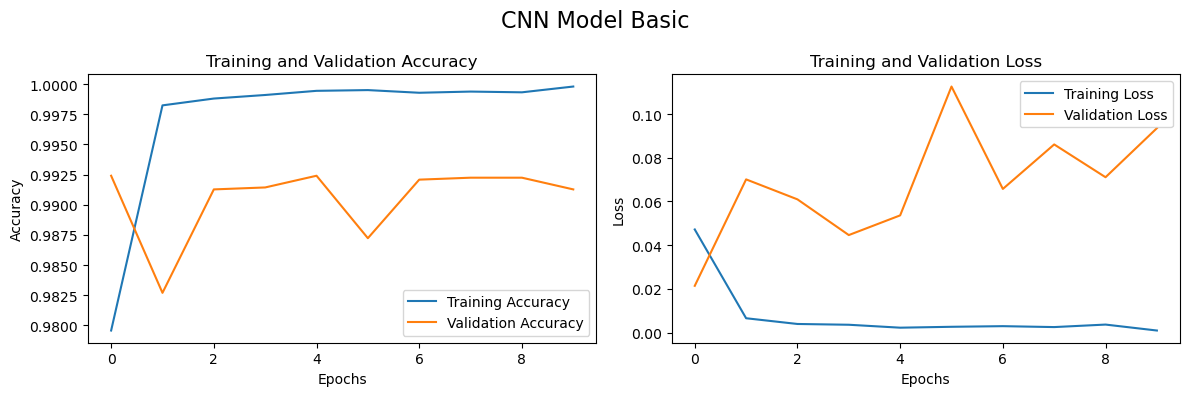

In [30]:
# Create a figure with subplots
plt.figure(figsize = (12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label = 'Training Loss')
plt.plot(history_cnn.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Add a title for the entire plot
plt.suptitle('CNN Model Basic', fontsize = 16)

# Display the plots
plt.tight_layout()
plt.show()

**Results and Performance Analysis**

1. Epoch-wise Training Results:

| Epoch | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss | Interpretation |
|-------|-------------------|---------------|---------------------|-----------------|----------------|
| 1     | 92.87%            | 0.1323        | 99.24%              | 0.0214          | The model learns quickly and performs exceptionally well on validation. |
| 2     | 99.84%            | 0.0059        | 98.27%              | 0.0701          | The model achieves high accuracy in training, but validation accuracy slightly drops, suggesting the possibility of overfitting. |
| 3     | 99.81%            | 0.0059        | 99.13%              | 0.0610          | Training accuracy remains very high, and validation accuracy improves slightly, showing good generalization. |
| 4     | 99.94%            | 0.0022        | 99.14%              | 0.0446          | Training loss continues to decrease, while validation accuracy remains high, with minimal loss. |
| 5     | 99.93%            | 0.0026        | 99.24%              | 0.0536          | High training performance continues with consistent validation results. |
| 6     | 99.97%            | 0.00098       | 98.72%              | 0.1126          | Training accuracy reaches near perfection, but validation performance fluctuates, suggesting potential overfitting. |
| 7     | 99.91%            | 0.0039        | 99.21%              | 0.0657          | Slight drops in validation loss, indicating stable performance. |
| 8     | 99.93%            | 0.0029        | 99.22%              | 0.0861          | The model continues to perform excellently, though validation loss shows a minor increase. |
| 9     | 99.89%            | 0.0056        | 99.22%              | 0.0711          | Training accuracy remains high, and validation accuracy holds steady, but validation loss slightly increases. |
| 10    | 99.97%            | 0.0012        | 99.13%              | 0.0935          | Training performance is nearly perfect, but validation accuracy fluctuates, potentially showing some overfitting. |


3. Test Set Performance:
- Test Accuracy: 99.04%
- Test Loss: 0.1293

4. Accuracy & Loss Analysis Graphs

```Training and Validation Accuracy Graph (Left):```
- The training accuracy rapidly reaches nearly 100%, demonstrating that the model quickly fits the training data.
- The validation accuracy fluctuates more, with a lower average than the training accuracy, indicating potential overfitting.

```Training and Validation Loss Graph (Right):```
- The training loss drops to almost zero, while the validation loss remains higher and shows variability.
- The inconsistent validation loss curve highlights instability during training, suggesting overfitting.

5. Key Takeaways:
- The model might be too complex or insufficiently regularized, causing it to memorize the training data without generalizing well.
- The unstable validation loss curve indicates the model may struggle with generalization.

#### 6.2.2.  Convolutional Neural Networks (CNNs) - Tuning 1

**Key Differences and Improvements in CNN Model Tuning (Version 1)**

The optimized CNN model (cnn_model_tuned_v1) introduces several modifications to improve performance and reduce overfitting, compared to the basic model (cnn_model_basic). 

`1. Regularization Added`
- L2 Regularization (kernel_regularizer=l2(0.001)) is applied to convolutional and dense layers to reduce overfitting.
- Dropout Increased (0.4 in the first dense layer and 0.3 in the second) to enhance generalization.

`2. Batch Normalization`
- Newly added after each Conv1D layer to stabilize training and speed up convergence.

`3. Architecture Refinements`

The tuned model includes three convolutional blocks, each consisting of:
- A Conv1D layer for extracting features.
- Batch Normalization for normalization.
- MaxPooling for reducing spatial dimensions. By adding a third convolutional block, the model can capture more complex features from the data, which is beneficial for improving its learning capacity.

`4. Learning Rate Adjusted`
- The learning rate is reduced to 0.0005 (was 0.001), allowing for more stable weight updates and better convergence.

`5. Early Stopping Implemented`
- Added ```EarlyStopping``` with ```patience=3```, preventing unnecessary epochs and reducing overfitting by restoring the best model.

**Expected Benefits**
- Better Generalization due to L2 regularization, dropout, and early stopping.
- More Stable Training with batch normalization and a lower learning rate.
- Potentially Higher Test Accuracy by refining feature extraction with increased filters.

In [32]:
# Define the optimized CNN model with Embedding Layer
cnn_model_tuned_v1 = Sequential([
    # Embedding Layer
    Embedding(input_dim = MAX_NB_WORDS, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH),
    
    # 1st Convolutional Block
    Conv1D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu', kernel_regularizer = l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    
    # 2nd Convolutional Block
    Conv1D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu', kernel_regularizer = l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    
    # 3rd Convolutional Block
    Conv1D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu', kernel_regularizer = l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    
    Flatten(),
    
    # Fully Connected Layers
    Dense(128, activation = 'relu', kernel_regularizer = l2(0.001)),
    Dropout(0.4),  
    
    Dense(64, activation = 'relu', kernel_regularizer = l2(0.001)),
    Dropout(0.3),

    Dense(1, activation = 'sigmoid')  # Binary classification output
])

# Compile the optimized model
cnn_model_tuned_v1.compile(
    optimizer = Adam(learning_rate = 0.0005),  
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor = 'val_loss',  
    patience = 3,          
    restore_best_weights = True,  
    verbose = 1
)

# Train the optimized CNN model with EarlyStopping
history_cnn_v1 = cnn_model_tuned_v1.fit(
    X_train_smote, y_train_smote, 
    validation_data = (X_val_pad, y_val),  
    epochs = 10, 
    batch_size = 64,
    callbacks = [early_stopping],  
    verbose = 1
)

print("\nModel training completed.")

# Evaluate on test set
test_loss, test_accuracy = cnn_model_tuned_v1.evaluate(X_test_pad, y_test) 
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the optimized model
cnn_model_tuned_v1.save('../saved models 2/cnn_model_tuned_v1.keras')

print("\nModel saved successfully!")

Epoch 1/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 578s 448ms/step - accuracy: 0.8025 - loss: 0.9548 - val_accuracy: 0.9908 - val_loss: 0.3414
Epoch 2/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 614s 442ms/step - accuracy: 0.9951 - loss: 0.2681 - val_accuracy: 0.9819 - val_loss: 0.1865
Epoch 3/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 556s 437ms/step - accuracy: 0.9969 - loss: 0.1158 - val_accuracy: 0.9922 - val_loss: 0.0818
Epoch 4/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 584s 459ms/step - accuracy: 0.9977 - loss: 0.0545 - val_accuracy: 0.9470 - val_loss: 0.2481
Epoch 5/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 574s 451ms/step - accuracy: 0.9984 - loss: 0.0356 - val_accuracy: 0.9884 - val_loss: 0.0734
Epoch 6/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 607s 439ms/step - accuracy: 0.9985 - loss: 0.0314 - val_accuracy: 0.9897 - val_loss: 0.0621
Epoch 7/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 568s 443ms/step - accuracy: 0.9981 - loss: 0.0289 - val_accuracy: 0.9119 - val_loss: 0.7381
Epoch 8/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 559s 440ms/step - ac

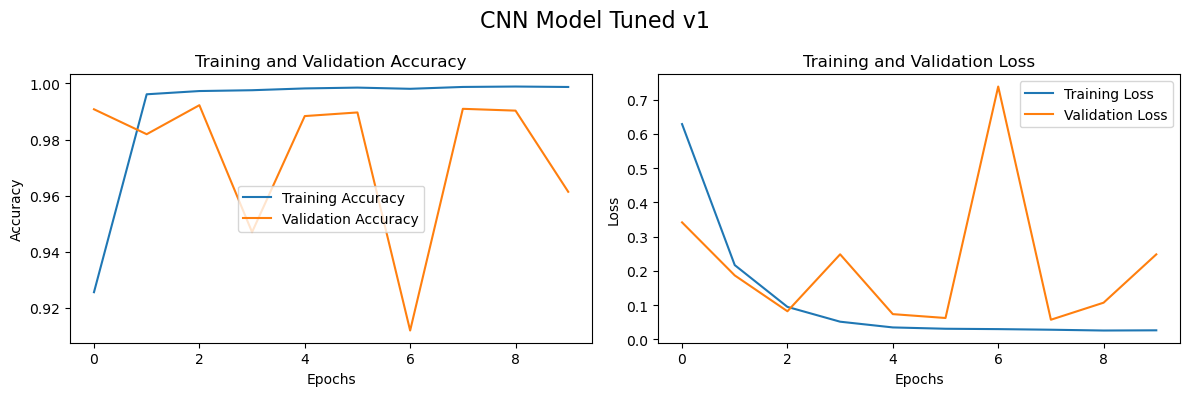

In [33]:
# Create a figure with subplots
plt.figure(figsize = (12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn_v1.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_cnn_v1.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn_v1.history['loss'], label = 'Training Loss')
plt.plot(history_cnn_v1.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Add a title for the entire plot
plt.suptitle('CNN Model Tuned v1', fontsize = 16)

# Display the plots
plt.tight_layout()
plt.show()

**Results and Performance Analysis**

1. Epoch-wise Training Results:


| Epoch | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss | Interpretation |
|-------|-------------------|---------------|---------------------|-----------------|----------------|
| 1     | 80.25%            | 0.9548        | 99.08%              | 0.3414          | The model starts with low training accuracy but performs very well on validation. |
| 2     | 99.51%            | 0.2681        | 98.19%              | 0.1865          | Significant improvement in training accuracy, while validation accuracy decreases slightly. |
| 3     | 99.69%            | 0.1158        | 99.22%              | 0.0818          | Both training and validation accuracies continue to improve, with reduced validation loss. |
| 4     | 99.77%            | 0.0545        | 94.70%              | 0.2481          | Training accuracy remains high, but validation accuracy drops significantly, indicating potential overfitting. |
| 5     | 99.84%            | 0.0356        | 98.84%              | 0.0734          | Training accuracy continues to rise, and validation accuracy recovers, suggesting better generalization. |
| 6     | 99.85%            | 0.0314        | 98.97%              | 0.0621          | Training accuracy is near perfect, and validation accuracy remains high, indicating strong generalization. |
| 7     | 99.81%            | 0.0289        | 91.19%              | 0.7381          | Validation accuracy drops significantly, and validation loss increases, suggesting overfitting or an anomaly. |
| 8     | 99.76%            | 0.0407        | 99.09%              | 0.0571          | Validation accuracy improves, and validation loss decreases, suggesting better model performance. |
| 9     | 99.87%            | 0.0283        | 99.03%              | 0.1068          | Training accuracy remains high, and validation accuracy stays strong, with minor fluctuations in validation loss. |
| 10    | 99.89%            | 0.0271        | 96.14%              | 0.2479          | Slight drop in validation accuracy, and an increase in validation loss indicates potential overfitting. |


3. Test Set Performance:
- Test Accuracy: 99.08%
- Test Loss: 0.0615

4. Accuracy & Loss Analysis Graphs

```Training and Validation Accuracy Graph (Left):```
- The training accuracy is consistently high, but the validation accuracy varies significantly between epochs.
- The sharp drop in validation accuracy around epoch 6 suggests a model instability or sensitivity to the training process.

```Training and Validation Loss Graph (Right):```
- The training loss steadily decreases, but the validation loss shows extreme spikes, particularly around epoch 6.
- These spikes in validation loss suggest overfitting or issues with the model's robustness.

5. Key Takeaways:
- The model might benefit from additional regularization techniques, such as dropout or weight decay, to improve stability.
- Despite the validation instability, the model achieved the best test accuracy among all models.

#### 6.2.3. Convolutional Neural Networks (CNNs) - Tuning 2

**Key Differences and Improvements in CNN Model Tuning (Version 2)**

1. `Increased Depth and Number of Filters in Convolutional Layers`
- Adds more depth and complexity by using three convolutional layers with increasing filter sizes: 128, 256, and 256 filters. This allows the model to capture more complex patterns and features from the input data.
- The increased number of filters in later layers (256) helps to extract more high-level features, which is especially beneficial when dealing with complex patterns like text data.

2. `Higher Regularization with L2`
- Increased L2 regularization to 0.001 in all layers (conv and dense). This stronger regularization helps prevent overfitting, especially with the increased complexity of the model (i.e., more filters and layers).

3. `Improved Fully Connected Layers`
- The first dense layer now has 256 neurons with 0.5 dropout, offering a higher capacity to learn complex representations.
- The second dense layer has 128 neurons and a 0.4 dropout rate, offering better regularization and learning capacity.

4. `Learning Rate Adjustment (ReduceLROnPlateau)`
- Implements a learning rate scheduler with ReduceLROnPlateau. This callback reduces the learning rate by a factor of 0.5 if the validation loss doesn't improve for 3 epochs. This helps the model converge faster and more smoothly as it adapts its learning rate during training.

5. More Dropout Regularization
- Applies dropout with 0.5 in the first fully connected layer and 0.4 in the second one, ensuring effective regularization to combat overfitting.
The increased dropout rate in the first layer (0.5) is a response to the increased complexity of the model with more filters and layers.

7. Optimizer
- Adam optimizer with a lower learning rate of 0.0001, ensuring more precise updates to the model's parameters, especially as the complexity increases with more layers.

In [34]:
cnn_model_tuned_v2 = Sequential([
    Embedding(input_dim = MAX_NB_WORDS, output_dim = EMBEDDING_DIM, input_length = MAX_SEQUENCE_LENGTH),
    
    Conv1D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu', kernel_regularizer = l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    
    Conv1D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu', kernel_regularizer = l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    
    Conv1D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu', kernel_regularizer = l2(0.001)),
    BatchNormalization(),
    MaxPooling1D(pool_size = 2),
    
    Flatten(),
    
    Dense(256, activation = 'relu', kernel_regularizer = l2(0.001)),
    Dropout(0.5),
    
    Dense(128, activation = 'relu', kernel_regularizer = l2(0.001)),
    Dropout(0.4),
    
    Dense(1, activation = 'sigmoid')
])

cnn_model_tuned_v2.compile(
    optimizer = Adam(learning_rate = 0.0001),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

# Learning rate scheduler
lr_scheduler = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 3, verbose = 1)

# Define EarlyStopping
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True, verbose = 1)


# Train with updated parameters
history_cnn_v2 = cnn_model_tuned_v2.fit(
    X_train_smote, y_train_smote, 
    validation_data = (X_val_pad, y_val),
    epochs = 10,
    batch_size = 64,
    callbacks = [early_stopping, lr_scheduler],
    verbose = 1
)

print("\nModel training completed.")

# Evaluate on test set
test_loss, test_accuracy = cnn_model_tuned_v2.evaluate(X_test_pad, y_test) 
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the optimized model
cnn_model_tuned_v2.save('../saved models 2/cnn_model_tuned_v2.keras')

print("\nModel saved successfully!")

Epoch 1/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1461s 1s/step - accuracy: 0.7433 - loss: 1.6803 - val_accuracy: 0.9846 - val_loss: 1.0336 - learning_rate: 1.0000e-04
Epoch 2/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1429s 1s/step - accuracy: 0.9919 - loss: 0.9313 - val_accuracy: 0.9924 - val_loss: 0.7163 - learning_rate: 1.0000e-04
Epoch 3/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1426s 1s/step - accuracy: 0.9970 - loss: 0.6324 - val_accuracy: 0.9884 - val_loss: 0.5091 - learning_rate: 1.0000e-04
Epoch 4/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1423s 1s/step - accuracy: 0.9979 - loss: 0.4205 - val_accuracy: 0.9884 - val_loss: 0.3576 - learning_rate: 1.0000e-04
Epoch 5/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1416s 1s/step - accuracy: 0.9969 - loss: 0.3050 - val_accuracy: 0.9890 - val_loss: 0.3021 - learning_rate: 1.0000e-04
Epoch 6/10
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 1439s 1s/step - accuracy: 0.9987 - loss: 0.2041 - val_accuracy: 0.9932 - val_loss: 0.1917 - learning_rate: 1.0000e-04
Epoch 7/10
1272/1272 ━━━━━━━━━━━━━━━━━━━

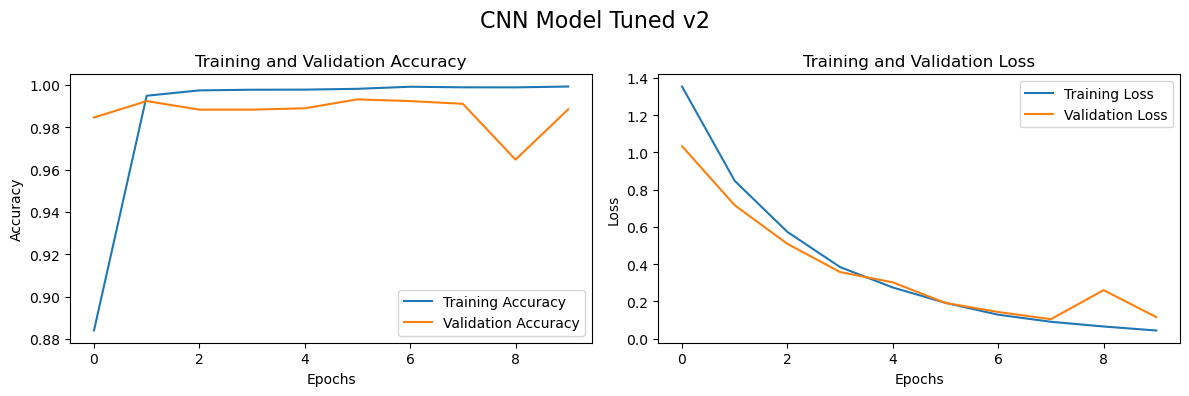

In [35]:
# Create a figure with subplots
plt.figure(figsize = (12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn_v2.history['accuracy'], label = 'Training Accuracy')
plt.plot(history_cnn_v2.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn_v2.history['loss'], label = 'Training Loss')
plt.plot(history_cnn_v2.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Add a title for the entire plot
plt.suptitle('CNN Model Tuned v2', fontsize = 16)

# Display the plots
plt.tight_layout()
plt.show()

**Results and Performance Analysis**

1. Epoch-wise Training Results:

| Epoch | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss | Learning Rate | Interpretation |
|-------|-------------------|---------------|---------------------|-----------------|---------------|----------------|
| 1     | 74.33%            | 1.6803        | 98.46%              | 1.0336          | 1.0000e-04    | The model starts with low training accuracy, but validation accuracy is high. |
| 2     | 99.19%            | 0.9313        | 99.24%              | 0.7163          | 1.0000e-04    | Significant improvement in training accuracy, and validation accuracy is also high. |
| 3     | 99.70%            | 0.6324        | 98.84%              | 0.5091          | 1.0000e-04    | Both training and validation accuracies improve, with reduced validation loss. |
| 4     | 99.79%            | 0.4205        | 98.84%              | 0.3576          | 1.0000e-04    | Training accuracy continues to improve, and validation accuracy remains stable. |
| 5     | 99.69%            | 0.3050        | 98.90%              | 0.3021          | 1.0000e-04    | Training accuracy remains high, and validation accuracy stays stable with a decrease in loss. |
| 6     | 99.87%            | 0.2041        | 99.32%              | 0.1917          | 1.0000e-04    | High accuracy for both training and validation with low validation loss. |
| 7     | 99.91%            | 0.1434        | 99.24%              | 0.1430          | 1.0000e-04    | Very high accuracy with further decrease in training loss and steady validation accuracy. |
| 8     | 99.87%            | 0.0989        | 99.11%              | 0.1045          | 1.0000e-04    | Training accuracy is near perfect, and validation accuracy remains high. |
| 9     | 99.86%            | 0.0714        | 96.47%              | 0.2604          | 1.0000e-04    | Training accuracy remains high, but there is a significant drop in validation accuracy. |
| 10    | 99.96%            | 0.0471        | 98.85%              | 0.1159          | 1.0000e-04    | Training accuracy reaches near perfection, and validation accuracy improves again. |


3. Test Set Performance:
- Test Accuracy: 98.81%
- Test Loss: 0.1270

4. Accuracy & Loss Analysis Graphs

```Training and Validation Accuracy Graph (Left):```
- The training accuracy quickly increases and remains high, with the validation accuracy closely following it.
- The minimal gap between the curves suggests the model generalizes well to new data.

```Training and Validation Loss Graph (Right):```
- Both training and validation losses decrease smoothly, with aligned curves showing stable learning.
- The final loss values are lower, indicating improved performance over the basic model.

5. Key Takeaways:
- This model demonstrates a strong balance between learning from the training data and maintaining performance on the validation set.
- The smooth and aligned loss curves reflect a well-tuned model with minimal overfitting.

#### 6.2.4. Making Predictions on Trained CNN Models and Evaluating Performance

This section evaluates the performance of multiple CNN models by making predictions on the test set, calculating performance metrics (accuracy, classification report, and confusion matrix), and visualizing the results in a comparative manner. It helps you to assess which model performs the best and understand its strengths and weaknesses in terms of classification accuracy and error distribution.

1. Loading Models and Making Predictions:

- For each model predictions are made on the reshaped test data ```(X_test_pad)``` by passing it through the model. Depending on whether the task is binary or multi-class classification, the predicted probabilities ```(y_pred_proba)``` are converted into class labels ```(y_pred)```.
Model Evaluation:

2. Model Evaluation:

- ```Accuracy:``` The percentage of correct predictions.
- ```Classification Report:``` This provides detailed metrics such as precision, recall, F1-score for each class.
- ```Confusion Matrix:``` A confusion matrix is calculated to show how well the model's predictions match the actual labels.

3. Storing Results:
- The results, including predictions, accuracy, classification report, and confusion matrix, are stored in the results dictionary for each model.

4. Confusion Matrix Visualization:
- A function is defined to plot confusion matrices for each model. Each confusion matrix shows the number of correct and incorrect predictions for each class, giving a visual understanding of how each model performed. 

Loading cnn_model_basic...
242/242 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step
cnn_model_basic Accuracy: 0.9904

Loading cnn_model_tuned_v1...
242/242 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step
cnn_model_tuned_v1 Accuracy: 0.9908

Loading cnn_model_tuned_v2...
242/242 ━━━━━━━━━━━━━━━━━━━━ 26s 107ms/step
cnn_model_tuned_v2 Accuracy: 0.9881

CNN Model Performance Comparison:

cnn_model_basic
Accuracy: 0.9904
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3491
           1       0.99      1.00      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730


cnn_model_tuned_v1
Accuracy: 0.9908
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3491
           1       0.99      0.99      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99   

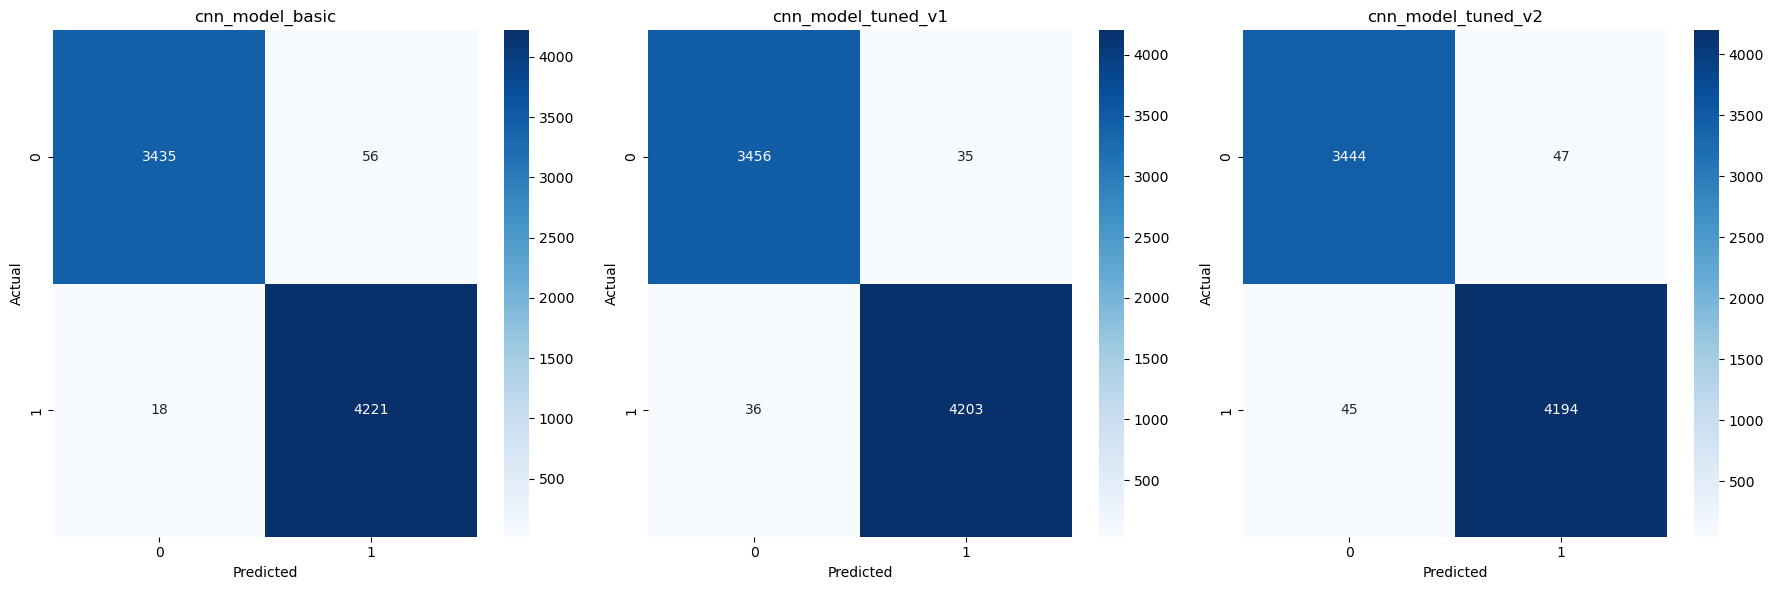

In [37]:
cnn_model_names = ["cnn_model_basic", "cnn_model_tuned_v1", "cnn_model_tuned_v2"]

# Dictionary to store results for CNN models
cnn_results = {}

# Load models, make predictions, and store results
for model_name in cnn_model_names:
    print(f"Loading {model_name}...")
    cnn_model = tf.keras.models.load_model(f'../saved models 2/{model_name}.keras')
    
    # Make predictions on test data
    y_pred_proba = cnn_model.predict(X_test_pad)
    
    # Convert probabilities to class labels
    if y_pred_proba.shape[1] == 1:  # Binary classification
        y_pred = (y_pred_proba > 0.5).astype("int32")  
    else:  # Multi-class classification
        y_pred = np.argmax(y_pred_proba, axis = 1)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict = True)
    
    # Save results for each model in a dictionary
    cnn_results[model_name] = {
        "predictions": y_pred,
        "accuracy": accuracy,
        "classification_report": class_report,
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    print(f"{model_name} Accuracy: {accuracy:.4f}\n")

# Function to visualize confusion matrices for CNN models
def plot_confusion_matrices(cnn_results):
    cnn_model_names = list(cnn_results.keys())
    fig, axes = plt.subplots(1, 3, figsize = (18, 6))  
    
    for ax, model_name in zip(axes.flat, cnn_model_names):
        cm = cnn_results[model_name]["confusion_matrix"]
        sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = np.unique(y_test), 
                    yticklabels = np.unique(y_test), ax = ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(f"{model_name}")

    plt.tight_layout()
    plt.show()

# Show performance comparison for CNN models
print("CNN Model Performance Comparison:")
for model_name, data in cnn_results.items():
    print(f"\n{model_name}")
    print(f"Accuracy: {data['accuracy']:.4f}")
    print(classification_report(y_test, data["predictions"]))

# Plot all confusion matrices
plot_confusion_matrices(cnn_results)

**Model Performance Comparison** 

**Classification Reports**

| Model                  | Accuracy | Precision (Class 0) | Recall (Class 0) | Precision (Class 1) | Recall (Class 1) | Observations                       |
|------------------------|----------|---------------------|------------------|---------------------|------------------|------------------------------------|
|  **CNN Model Basic**        | 99.04%   | 0.99                | 0.98             | 0.99                | 1.00             | High accuracy, well-balanced performance for both classes.|
|**CNN Model Tuned 1**        | 99.08%   | 0.99                | 0.99             | 0.99                | 0.99             | High accuracy, similar to the basic model|
| **CNN Model Tuned 2**       | 98.81%   | 0.99                | 0.99             | 0.99                | 0.99             | Very similar performance to the basic model with slightly lower accuracy. |


Analysis of Results:

1. ```Accuracy:```
   - All three models show excellent accuracy, ranging from 98.81% to 99.08%, with `cnn_model_tuned_v1` achieving the highest accuracy at 99.08%. These high accuracy values indicate that the models are performing very well on the test data, correctly classifying most of the test samples.

3. ```Precision, Recall, and F1-Score:```
   - For Class 0 (presumably the majority class), the precision and recall values are consistently high across all models (around 0.99), suggesting that the models are effective at identifying the majority class with minimal false positives or negatives.
   - For Class 1 (the minority class), the precision and recall remain strong across all models. `CNN Model Tuned 1` shows perfect recall (1.00) for Class 1, meaning it correctly identifies all instances of Class 1. However, the precision and recall for Class 1 are very similar across all models, maintaining values around 0.99, which is excellent.

3. ```Macro Average:```
   - The macro average precision, recall, and F1-score are all above 0.99 for all models, indicating that, on average, the models perform consistently well across both classes. There is no significant difference in performance between the two classes.

4. ```Weighted Average:```
   - The weighted average precision, recall, and F1-score are also near 0.99 for all models. This suggests that the models are effectively handling the class imbalance (since Class 0 has more instances) and are balancing the performance between both classes.


**Confusion matrices**

Key Metrics from Confusion Matrices:
  - `True Positives (TP):` Bottom-right cell (correctly predicted as 1)
  - `True Negatives (TN):` Top-left cell (correctly predicted as 0)
  - `False Positives (FP):` Top-right cell (incorrectly predicted as 1)
  - `False Negatives (FN):` Bottom-left cell (incorrectly predicted as 0)

| Model                | TN   | FP  | FN  | TP   | Observations |
|----------------------|------|-----|-----|------|--------------------------------------------------------------------------------------|
| **CNN Model Basic**  | 3435 | 56  | 18  | 4221 | High true positives and low false negatives, indicating good sensitivity but slightly higher false positives.|
| **CNN Model Tuned 1** | 3456 | 35  | 36  | 4203 |Improved false positives compared to the basic model, but with a trade-off of slightly higher false negatives. |
| **CNN Model RS Best** | 3444 | 47  | 45  | 4194 | Balanced performance, with a slight increase in both false positives and false negatives compared to the tuned model. |

**Random Prediction Sampling** 

The code selects 10 random examples of predicted vs actual values from each model's predictions and shuffles them for comparison. It performs the following steps:
1. Pairs predicted and actual values for each model.
2. Shuffles the pairs to ensure randomness.
3. Selects the first 10 shuffled examples for each model and stores them.
4. Prints the selected 10 examples for each model, showing both predicted and actual values.

This approach helps quickly inspect the performance of each model on a few random test cases, allowing for easy comparison and potential identification of issues or patterns in the model's predictions.

**Key Takeaways**

- `cnn_model_basic:` The predictions are consistently correct for Class 1 (the minority class), with all the predicted values matching the actual values. This indicates that the model is successfully classifying the instances of Class 1, showcasing high performance on the test set.

- `cnn_model_tuned_v1:` This model shows a mix of correct predictions for both Class 0 (majority class) and Class 1, with most predictions matching the actual values. While it correctly identifies instances of both classes, it is more successful with Class 1 than Class 0, which is consistent with the slightly improved recall for Class 1 observed in the performance metrics.

- `cnn_model_tuned_v2:` The predictions are correct and balanced between both classes.

In [38]:
# Select 10 shuffled example results for each model
cnn_example_results = {}

for model_name, data in cnn_results.items():
    # Get the predicted and actual pairs
    cnn_predicted_vs_actual = list(zip(data["predictions"], y_test))
    
    # Shuffle the examples
    np.random.shuffle(cnn_predicted_vs_actual)
    
    # Select 10 shuffled results
    cnn_example_results[model_name] = cnn_predicted_vs_actual[:10]

# Print 10 shuffled example predicted vs actual pairs for each model
for model_name, examples in cnn_example_results.items():
    print(f"\n{model_name} - Example Predicted vs Actual (Shuffled):")
    for i, (pred, actual) in enumerate(examples):
        print(f"Example {i+1}: Predicted = {pred}, Actual = {actual}")


cnn_model_basic - Example Predicted vs Actual (Shuffled):
Example 1: Predicted = [1], Actual = 1
Example 2: Predicted = [1], Actual = 1
Example 3: Predicted = [1], Actual = 1
Example 4: Predicted = [1], Actual = 1
Example 5: Predicted = [1], Actual = 1
Example 6: Predicted = [1], Actual = 1
Example 7: Predicted = [1], Actual = 1
Example 8: Predicted = [1], Actual = 1
Example 9: Predicted = [1], Actual = 1
Example 10: Predicted = [1], Actual = 1

cnn_model_tuned_v1 - Example Predicted vs Actual (Shuffled):
Example 1: Predicted = [0], Actual = 0
Example 2: Predicted = [0], Actual = 0
Example 3: Predicted = [1], Actual = 1
Example 4: Predicted = [1], Actual = 1
Example 5: Predicted = [0], Actual = 0
Example 6: Predicted = [1], Actual = 1
Example 7: Predicted = [1], Actual = 1
Example 8: Predicted = [1], Actual = 1
Example 9: Predicted = [1], Actual = 1
Example 10: Predicted = [1], Actual = 1

cnn_model_tuned_v2 - Example Predicted vs Actual (Shuffled):
Example 1: Predicted = [0], Actual 

#### 6.2.5. Best CNN Model Selection

**Model Comparison Summary**

| Model             | Test Accuracy | Test Loss |                                    
|-------------------|---------------|-----------|
| **CNN Model Basic**     | 99.04%        | 0.1293    |
| **CNN Model Tuned 1**   | 99.08%        | 0.0615    | 
| **CNN Model Tuned 2**   | 98.81%        | 0.1270    | 


**Overall Observations:**
- `Overfitting:` All models show signs of overfitting to some extent, especially in the basic `CNN Model Basic` and `CNN Model Tuned 1`. However, `CNN Model Tuned 2` stands out with better regularization and a smoother learning curve, which likely contributes to its stronger generalization.
- `Model Stability:` `CNN Model Tuned 2` offers the most stable performance, with consistent training and validation accuracy and lower loss. This model is likely the most robust and reliable for real-world predictions.
- `Test Accuracy:` All models perform well on the test set, with high test accuracy rates. However, the stability and alignment of validation results in `CNN Model Tuned 2` suggest it will likely perform best in real-world scenarios.

**Best Model Selection**

Based on the overall performance and stability, `CNN Model Tuned 2` is the most balanced and well-tuned model. Its ability to maintain high validation accuracy with minimal fluctuations indicates strong generalization, making it the best choice for deployment.

## 7. Fine-tuning Pretrained DistilBERT

**DistilBERT** is a smaller, faster version of BERT (Bidirectional Encoder Representations from Transformers), designed to maintain most of BERT's performance while being more efficient in terms of computational resources. It uses knowledge distillation, where a smaller model (the student) learns to replicate the behavior of a larger, pre-trained model (the teacher). DistilBERT retains around 97% of BERT's language understanding and is 60% faster while having 40% fewer parameters. It is a transformer-based model trained on large text corpora to understand and generate language representations, making it highly effective for natural language processing (NLP) tasks like sentiment analysis, question answering, and text classification.

Using a pre-trained model like DistilBERT offers several advantages:
- `Efficiency:` Training a deep neural network like BERT from scratch requires vast amounts of data and computational power. By leveraging a pre-trained model, we save time and resources since the model already has learned useful language features from large-scale data.
- `Better Performance:` A pre-trained model often provides better performance, especially when working with limited data. The model has already learned contextual representations of language, which it can apply to specific tasks with less fine-tuning.
- `Transfer Learning:` DistilBERT, being a general-purpose model trained on diverse language data, can be fine-tuned for specific tasks like text classification. Fine-tuning allows the model to adapt to the specific dataset with much less training data compared to training from scratch.

**Explanation of the Code:**
- `Subset of Data:` The code begins by creating a 10% subset of the training data `(X_train_final_10)` for faster experimentation. This allows to train the model on a small portion of the data before committing to full-scale training.
- `Tokenization:` The `DistilBertTokenizer` from Hugging Face's Transformers library is used to tokenize the text data. Tokenization breaks text into manageable units (tokens) that the model can process. The `max_length` is set to 128 to limit the input size, ensuring efficient processing. The `return_tensors='pt'` option ensures that the tokenized output is returned as PyTorch tensors, compatible with the model's input format.
- `Creating DataLoader:` After tokenizing, the code creates `TensorDataset` objects for training, validation, and test sets. These datasets store both the input tokens (input IDs and attention masks) and the corresponding labels. Then, `DataLoader` objects are created to load the data in batches of 8 for training, validation, and testing. This batch size is chosen to fit the model into memory during training.
- `Model Initialization:` The code loads the pre-trained `DistilBertForSequenceClassification` model from the Hugging Face model hub. It is fine-tuned for sequence classification tasks, and since we are working with two labels (fake vs. true news), the model is configured with num_labels=2.
- `Training:` The training loop is structured over three epochs. In each epoch, the model processes the training data in batches, computes the loss (difference between predicted and true labels), and performs backpropagation to update the model's parameters. The `AdamW` optimizer is used to minimize the loss. The training accuracy is calculated by comparing the predicted labels (with the highest logits) against the true labels.
- `Gradient Accumulation:` Since the model and dataset may be too large to fit in memory for large batch sizes, gradient accumulation is employed. This accumulates gradients over multiple steps before performing the weight update, simulating a larger batch size without needing more memory.
- `Evaluation:` After each training epoch, the model is evaluated on the validation set. Similar to the training process, the validation data is processed in batches, and predictions are made. The validation loss and accuracy are computed to assess model performance.
- `Model Evaluation (model.eval()):` The model is switched to evaluation mode, disabling dropout layers and enabling the evaluation of its performance without further weight updates.
- `Test Set Evaluation:` The code evaluates the model on the test dataset by iterating over the test DataLoader. The model makes predictions on the input texts, and the loss and accuracy are calculated for each batch.
- `Accuracy and Loss:` The code calculates the total test loss and accuracy by comparing the predicted labels (predictions) with the true labels (labels).
- `Classification Report:` After evaluating the model, the classification report is generated, providing metrics such as precision, recall, and F1-score for both classes.
- `Confusion Matrix:` The confusion matrix is plotted to visualize the true vs predicted labels. This helps assess how well the model performs on each class, showing where it may confuse predictions.
- `Saving the Model and Tokenizer:` The trained model and tokenizer are saved for future use or deployment, ensuring that they can be reloaded without needing to retrain the model.

In [21]:
# Define 10% subset of the data
X_train_final_10, _, y_train_final_10, _ = train_test_split(
    X_train_final, y_train_final, train_size=0.1, random_state=42, stratify=y_train_final
)

# Tokenization function for smaller batch processing
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_data(texts):
    # Tokenize in smaller chunks
    return tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors='pt')

# Tokenizing only a small subset of the data (limiting the batch size)
train_encodings = tokenize_data(X_train_final_10.tolist())
val_encodings = tokenize_data(X_val.tolist())
test_encodings = tokenize_data(X_test.tolist())

# Convert labels to tensor
train_labels = torch.tensor(y_train_final_10.tolist())
val_labels = torch.tensor(y_val.tolist())
test_labels = torch.tensor(y_test.tolist())

# Create DataLoader for training, validation, and test sets
train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], train_labels)
val_dataset = TensorDataset(val_encodings['input_ids'], val_encodings['attention_mask'], val_labels)
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_labels)

# Use smaller batch sizes for DataLoader to fit in memory
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [22]:
# Load pre-trained DistilBERT model for sequence classification
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up the AdamW optimizer
optimizer = AdamW(model.parameters(), lr=1e-5)

# Gradient Accumulation settings (accumulate over 4 steps to simulate a larger batch size)
gradient_accumulation_steps = 4
accumulated_steps = 0

# Training loop
epochs = 3
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    correct_train_predictions = 0  # Variable to track training accuracy

    # Training phase
    for batch in tqdm(train_dataloader, desc=f"Training Epoch {epoch+1}"):

        batch = tuple(b.to(device) for b in batch)  # Move batch to GPU
        input_ids, attention_mask, labels = batch

        optimizer.zero_grad()  # Clear gradients

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss += loss.item()  # Accumulate loss

        # Backward pass and optimization step
        loss.backward()

        # Update weights only after the gradient is accumulated
        if (accumulated_steps + 1) % gradient_accumulation_steps == 0:
            optimizer.step()
            accumulated_steps = 0  # Reset the counter
        else:
            accumulated_steps += 1

        # Calculate training accuracy
        predictions = torch.argmax(outputs.logits, dim=-1)
        correct_train_predictions += (predictions == labels).sum().item()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_accuracy = correct_train_predictions / len(train_dataset)  # Calculate accuracy
    print(f"Epoch {epoch + 1} | Training Loss: {avg_train_loss:.4f} | Training Accuracy: {train_accuracy * 100:.2f}%")

    # Evaluate on the validation set
    model.eval()
    total_val_loss = 0
    correct_val_predictions = 0

    for batch in tqdm(val_dataloader, desc=f"Evaluating Epoch {epoch+1}"):
        batch = tuple(b.to(device) for b in batch)  # Move batch to GPU
        input_ids, attention_mask, labels = batch

        with torch.no_grad():  # Disable gradients for evaluation
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()

            predictions = torch.argmax(outputs.logits, dim=-1)
            correct_val_predictions += (predictions == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_accuracy = correct_val_predictions / len(val_dataset)
    print(f"Epoch {epoch + 1} | Validation Loss: {avg_val_loss:.4f} | Validation Accuracy: {val_accuracy * 100:.2f}%")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Training Epoch 1: 100%|██████████| 310/310 [21:13<00:00,  4.11s/it]


Epoch 1 | Training Loss: 0.3282 | Training Accuracy: 90.90%


Evaluating Epoch 1: 100%|██████████| 773/773 [18:13<00:00,  1.41s/it]


Epoch 1 | Validation Loss: 0.0362 | Validation Accuracy: 99.84%


Training Epoch 2: 100%|██████████| 310/310 [21:02<00:00,  4.07s/it]


...

Epoch 2 | Validation Loss: 0.0190 | Validation Accuracy: 99.76%


Training Epoch 3: 100%|██████████| 310/310 [20:57<00:00,  4.06s/it]


Epoch 3 | Training Loss: 0.0231 | Training Accuracy: 99.84%


Evaluating Epoch 3: 100%|██████████| 773/773 [18:09<00:00,  1.41s/it]

Epoch 3 | Validation Loss: 0.0182 | Validation Accuracy: 99.50%


In [23]:
model.eval()  # Set model to evaluation mode
all_labels = []
all_predictions = []
total_test_loss = 0
correct_test_predictions = 0

for batch in tqdm(test_dataloader, desc="Evaluating on Test Set"):
    batch = tuple(b.to(device) for b in batch)
    input_ids, attention_mask, labels = batch

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_test_loss += loss.item()

        predictions = torch.argmax(outputs.logits, dim=-1)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

        correct_test_predictions += (predictions == labels).sum().item()

avg_test_loss = total_test_loss / len(test_dataloader)
test_accuracy = correct_test_predictions / len(test_dataset)

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Save the model and tokenizer
model.save_pretrained('../saved models 2/distilbert_pretrained_v1')
tokenizer.save_pretrained('../saved models 2/tokenizer_pretrained_v1')
print("Model and tokenizer saved successfully!")

Evaluating on Test Set: 100%|██████████| 967/967 [33:40<00:00,  2.09s/it]


Test Loss: 0.0161
Test Accuracy: 99.66%
Model and tokenizer saved successfully!


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3491
           1       1.00      0.99      1.00      4239

    accuracy                           1.00      7730
   macro avg       1.00      1.00      1.00      7730
weighted avg       1.00      1.00      1.00      7730



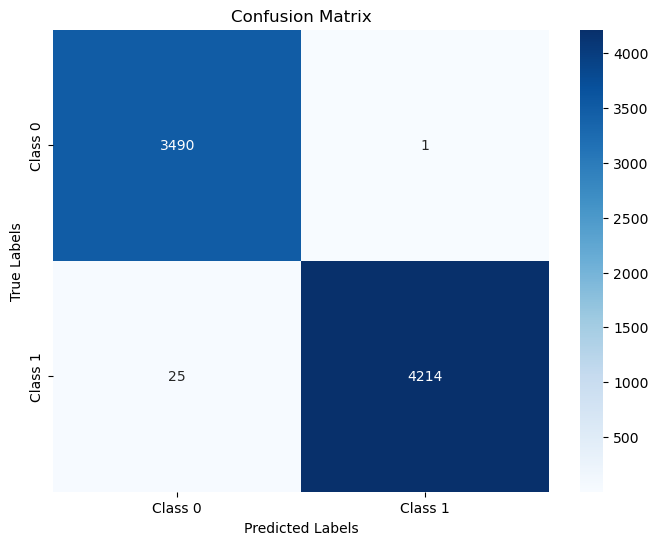

In [24]:
# Generate classification report
print("Classification Report:")
print(classification_report(all_labels, all_predictions))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

**Results and Performance Analysis**

The results demonstrate the effectiveness of the DistilBERT pre-trained model for sequence classification:
- `Training Accuracy:` By the end of the third epoch, the training accuracy reaches 99.84%, indicating that the model has effectively learned to classify the training data. The high accuracy shows that the model is able to correctly identify the labels of news articles with minimal error.
- `Validation Accuracy:` The validation accuracy also remains high, peaking at 99.84% in the first epoch and slightly dropping to 99.50% in the third epoch. A minor decline in validation accuracy between epochs is normal and could suggest minor overfitting, but the overall performance is good.
- `Loss Values:` The loss values, which measure how far off the model's predictions are from the actual labels, steadily decrease over the epochs, from 0.3282 in the first epoch to 0.0231 in the third epoch for training, and similarly decrease in the validation set. Lower loss values correlate with better model performance.
- `Performance on 10% Subset:` Training on only 10% of the data shows that the model is highly capable of learning even from a smaller sample, providing useful insights without requiring the full dataset.

**Evaluation Results**
- `Test Accuracy:` The model achieves an impressive test accuracy of 99,66%. This indicates that the model is performing well on the unseen test data.
- `Precision, Recall, and F1-Score:` The classification report shows that the model's precision, recall, and F1-score for both classes are very high, close to 1.00. This suggests that the model is consistently making correct predictions for both classes.
- `Confusion Matrix:` The confusion matrix further supports this, showing almost perfect classification with minimal misclassifications. The high accuracy across both classes suggests that the model generalizes well to the test data.

| Model                         | TN   | FP  | FN  | TP   | Observations |
|----------------------         |------|-----|-----|------|--------------------------------------------------------------------------------------|
| **Distilbert Pretrained v1**  | 3490 | 1   | 25  | 4214 | Overall, the model's performance indicates excellent classification capability, with only a slight number of missed positive instances and minimal incorrect predictions in the negative class. This points to strong generalization on the test data.|

## 8. Model Comparison: Best MLP and CNN Models vs Distilbert Pretrained Model



**Performance Metrics**

| Model                        | Test Accuracy | Test Loss | Precision (Class 0) | Recall (Class 0) | Precision (Class 1) | Recall (Class 1) |
|----------------------        |---------------|-----------|---------------------|------------------|---------------------|------------------|
| **MLP Model Tuned 2**        | 99.04%        | 0.0817    | 0.98                | 0.99             | 1.00                | 0.99             |
| **CNN Model Tuned 2**        | 98.81%        | 0.1270    | 0.99                | 0.99             | 0.99                | 0.99             |
| **Distilbert Pretrained v1** | 99.66%        | 0.0161    | 0.99                | 1.00             | 1.00                | 0.99             |

**Final Conclusion:**
- `DistilBERT Pretrained v1` clearly outperforms both the MLP and CNN models, achieving the highest test accuracy (99.66%) with near-perfect precision, recall, and F1-score for both classes. It also has the lowest loss value (0.0161), indicating optimal model performance and generalization.
- `MLP Model Tuned 2` follows closely with 99.04% accuracy and high precision/recall for both classes, making it a strong alternative if a simpler model is preferred. Its slightly lower accuracy and recall for Class 0 (compared to DistilBERT) might be a trade-off.
- `CNN Model Tuned 2` has the lowest performance in this comparison, with the highest loss (0.1270) and a slight drop in precision/recall for Class 1. While it performs well, it is less effective than the other two models.

Given the results, `DistilBERT Pretrained v1` would be the best choice for achieving the highest classification performance, especially for tasks requiring minimal misclassifications and strong generalization.

## 8. References

- Original Dataset: [Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset/data)
- Multi-Layer Perceptron Theory: [Multi-Layer Perceptron](https://www.geeksforgeeks.org/multi-layer-perceptron-learning-in-tensorflow/)
- Convolution Neural Network Theory: [Introduction to Convolution Neural Network](https://www.geeksforgeeks.org/introduction-convolution-neural-network/)
- Synthetic Minority Oversampling Technique (SMOTE): [SMOTE](https://www.analyticsvidhya.com/blog/2020/10/overcoming-class-imbalance-using-smote-techniques/)
- Hyperparameter Tuning Using Randomized Search: [Randomized Search](https://www.analyticsvidhya.com/blog/2022/11/hyperparameter-tuning-using-randomized-search/)
- Adaptive Moment Estimation (Adam) Theory: [What is Adam Optimizer](https://www.geeksforgeeks.org/adam-optimizer/)
- ReLU (Rectified Linear Unit) Theory: [An Introduction to the ReLU Activation Function](https://builtin.com/machine-learning/relu-activation-function)